In [ ]:

import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import hashlib
from pathlib import Path
from PIL import Image
import numpy as np
from collections import Counter

# Configuration'Test', 'Valid', 'Train'

train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

# Folders to check
folders = {'Train': train_dir, 'Valid': valid_dir, 'Test': test_dir}

# Lists to store cleaned files
corrupted_images = []
non_image_files = []
duplicate_files = []
cleaned_data = {}

def get_file_hash(file_path):
    """Generate MD5 hash to find duplicates"""
    with open(file_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def is_valid_image(file_path):
    """Check if file is a valid image"""
    try:
        img = Image.open(file_path)
        img.verify()  # Verify it's an image
        img = Image.open(file_path)  # Re-open after verify
        img.load()  # Load image to check for errors
        return True
    except Exception:
        return False

def clean_dataset(folders):
    print("="*60)
    print("STARTING DATASET CLEANING")
    print("="*60)

    all_hashes = {}
    total_images = 0

    for folder_name, folder_path in folders.items():
        print(f"\n--- Checking {folder_name.upper()} folder ---")

        if not os.path.exists(folder_path):
            print(f"⚠️  Path not found: {folder_path}")
            continue

        class_names = os.listdir(folder_path)
        print(f"Classes found: {class_names}")

        cleaned_data[folder_name] = {}

        for class_name in class_names:
            class_path = os.path.join(folder_path, class_name)
            if not os.path.isdir(class_path):
                continue

            image_files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
            cleaned_data[folder_name][class_name] = []

            class_total = 0
            class_corrupted = 0
            class_non_img = 0
            class_dupes = 0

            for img_file in image_files:
                img_path = os.path.join(class_path, img_file)
                file_ext = os.path.splitext(img_file)[1].lower()

                # 1. Check if it's a valid image file extension
                valid_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp']
                if file_ext not in valid_extensions:
                    non_image_files.append(img_path)
                    class_non_img += 1
                    print(f"⚠️  Non-image file: {img_path}")
                    continue

                # 2. Check if image is corrupted
                if not is_valid_image(img_path):
                    corrupted_images.append(img_path)
                    class_corrupted += 1
                    print(f"❌ Corrupted: {img_path}")
                    continue

                # 3. Check for duplicates (within same class or whole dataset)
                try:
                    file_hash = get_file_hash(img_path)
                    if file_hash in all_hashes:
                        duplicate_files.append((img_path, all_hashes[file_hash]))
                        class_dupes += 1
                        print(f"🔄 Duplicate found: {img_path}")
                        continue
                    all_hashes[file_hash] = img_path
                except Exception as e:
                    print(f"Error hashing {img_path}: {e}")
                    continue

                # If passed all checks, add to cleaned data
                cleaned_data[folder_name][class_name].append(img_path)
                class_total += 1

            print(f"  Class '{class_name}': {class_total} valid images")
            if class_corrupted > 0:
                print(f"    - Removed {class_corrupted} corrupted")
            if class_non_img > 0:
                print(f"    - Removed {class_non_img} non-image files")
            if class_dupes > 0:
                print(f"    - Removed {class_dupes} duplicates")

            total_images += class_total

    print("\n" + "="*60)
    print("CLEANING SUMMARY")
    print("="*60)
    print(f"Total valid images found: {total_images}")
    print(f"Corrupted images removed: {len(corrupted_images)}")
    print(f"Non-image files removed: {len(non_image_files)}")
    print(f"Duplicate images removed: {len(duplicate_files)}")

# Run cleaning
clean_dataset(folders)

# Check Class Imbalance
print("\n" + "="*60)
print("CLASS IMBALANCE CHECK")
print("="*60)

for folder_name, folder_path in folders.items():
    if not os.path.exists(folder_path):
        continue
    print(f"\n{folder_name.upper()} Set:")
    counts = {}
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if os.path.isdir(class_path):
            # Count valid images only
            valid_count = len([f for f in os.listdir(class_path)
                              if os.path.isfile(os.path.join(class_path, f)) and
                              f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp'))])
            counts[class_name] = valid_count

    for cls, count in counts.items():
        print(f"  {cls}: {count} images")

    # Check imbalance
    if counts:
        max_count = max(counts.values())
        min_count = min(counts.values())
        if max_count / min_count > 2:
            print(f"  ⚠️  WARNING: Imbalanced dataset! Ratio: {max_count/min_count:.2f}:1")
        else:
            print(f"  ✅ Dataset is balanced")

print("\n✅ Data cleaning complete!")

STARTING DATASET CLEANING

--- Checking TRAIN folder ---
Classes found: ['Wisdom', 'Damage', 'Infection', 'Cavities']
  Class 'Wisdom': 1478 valid images
  Class 'Damage': 504 valid images
  Class 'Infection': 742 valid images
  Class 'Cavities': 964 valid images

--- Checking VALID folder ---
Classes found: ['Wisdom', 'Infection', 'Cavities', 'Damage']
🔄 Duplicate found: /content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification/Valid/Wisdom/Wisdom_2095.jpg
🔄 Duplicate found: /content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification/Valid/Wisdom/Wisdom_2099.jpg
🔄 Duplicate found: /content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification/Valid/Wisdom/Wisdom_2112.jpg
🔄 Duplicate found: /content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification/Valid/Wisdom/Wisdom_2104.jpg
🔄 Duplicate found: /content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classifi

In [ ]:
# Optional: Delete bad files automatically
print("\n--- Deleting bad files ---")

def delete_files(file_list, label):
    count = 0
    for path in file_list:
        try:
            if os.path.exists(path):
                os.remove(path)
                count += 1
        except Exception as e:
            print(f"Error deleting {path}: {e}")
    print(f"Deleted {count} {label}")

if len(corrupted_images) > 0 or len(non_image_files) > 0 or len(duplicate_files) > 0:
    confirm = input("Do you want to DELETE these files? Type 'yes': ")
    if confirm.lower() == 'yes':
        delete_files(corrupted_images, "corrupted images")
        delete_files(non_image_files, "non-image files")
        # For duplicates, delete the second one found (the new one)
        delete_files([d[0] for d in duplicate_files], "duplicate images")
        print("✅ Bad files removed!")
    else:
        print("❌ Files kept in folder.")
else:
    print("✅ No bad files found to delete.")


--- Deleting bad files ---
Do you want to DELETE these files? Type 'yes': yes
Deleted 0 corrupted images
Deleted 0 non-image files
Deleted 27 duplicate images
✅ Bad files removed!


In [ ]:
# Import necessary libraries
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Check Dataset Structure

print("Folders in classification:", os.listdir(data_path))

# Check Train folder to see how many classes (labels) we have
train_path = os.path.join(data_path, 'Train')
class_names = os.listdir(train_path)
print(f"Number of Classes: {len(class_names)}")
print(f"Class Names: {class_names}")

Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders in classification: ['Test', 'Valid', 'Train']
Number of Classes: 4
Class Names: ['Wisdom', 'Damage', 'Infection', 'Cavities']


In [ ]:
# Configuration
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 12 # Adjust based on how long you want to wait
LEARNING_RATE = 1e-4

# Define Paths

train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

# Transforms
# Training data gets augmented (flips, rotation, color jitter)
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet stats
])

# Validation and Test data only need resizing and normalizing
test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Data
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Get Class Names
class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Loaded {num_classes} classes.")

Loaded 4 classes.


In [ ]:
# Load EfficientNet-B0 Pre-trained
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Freeze early layers (optional, but keeps training fast)
# for param in model.parameters():
#     param.requires_grad = False

# Replace the classifier head to match your number of classes
# EfficientNet B0 has a classifier with 1280 features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(model.classifier[1].in_features, num_classes)
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 50.4MB/s]


Total parameters: 4,012,672
Trainable parameters: 4,012,672


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Learning Rate Scheduler - helps push accuracy past 90%
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

In [ ]:
import os

# Check the exact structure
base = "/content/drive/MyDrive/Dental OPG Image dataset"
print("Contents of base folder:")
print(os.listdir(base))

# Check inside the nested folder
nested = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset"
print("\nContents of nested folder:")
print(os.listdir(nested))

Contents of base folder:
['Dental OPG Image dataset']

Contents of nested folder:
['Classification', 'Object detection']


In [ ]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ✅ CORRECTED PATH
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"

# Configuration - Optimized for FAST execution
IMAGE_SIZE = 224
BATCH_SIZE = 64  # Larger batch for faster training
NUM_EPOCHS = 20
LEARNING_RATE = 3e-4

train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

print("="*60)
print("STEP 1: CLEANING DATASET")
print("="*60)

def clean_folder(folder_path, folder_name):
    """Remove corrupted/missing images"""
    removed = 0
    valid_files = []

    if not os.path.exists(folder_path):
        print(f"⚠️ {folder_name} folder not found")
        return []

    classes = os.listdir(folder_path)
    for cls in classes:
        cls_path = os.path.join(folder_path, cls)
        if not os.path.isdir(cls_path):
            continue
        for img_file in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_file)
            try:
                img = Image.open(img_path)
                img.verify()
                valid_files.append(img_path)
            except:
                print(f"❌ Removed corrupted: {img_path}")
                removed += 1
                os.remove(img_path)

    print(f"✅ {folder_name} cleaned: {removed} corrupted files removed")
    return valid_files

# Clean all folders
clean_folder(train_dir, "Train")
clean_folder(valid_dir, "Valid")
clean_folder(test_dir, "Test")

print("\n" + "="*60)
print("STEP 2: LOADING DATA (num_workers=0 for stability)")
print("="*60)

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Data - num_workers=0 to avoid Google Drive issues
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Train samples: {len(train_dataset)}, Valid samples: {len(valid_dataset)}, Test samples: {len(test_dataset)}")

print("\n" + "="*60)
print("STEP 3: BUILDING MODEL (EfficientNet-B0)")
print("="*60)

# Load EfficientNet-B0
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(model.classifier[1].in_features, num_classes)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print("Model loaded successfully!")

print("\n" + "="*60)
print("STEP 4: TRAINING")
print("="*60)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

# Training
best_acc = 0.0
best_model_path = "best_dental_model.pth"

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, valid_loader, criterion, device)
    scheduler.step()

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"*** Best Model Saved! Accuracy: {best_acc:.2f}% ***")

# Final Test Evaluation
model.load_state_dict(torch.load(best_model_path))
_, test_acc = validate(model, test_loader, criterion, device)

print("\n" + "="*50)
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
print("="*50)

if test_acc >= 95:
    print("✅ SUCCESS: Target achieved!")
else:
    print(f"⚠️ Target not met. Need {95 - test_acc:.2f}% more.")

Using device: cuda
STEP 1: CLEANING DATASET
✅ Train cleaned: 0 corrupted files removed
✅ Valid cleaned: 0 corrupted files removed
✅ Test cleaned: 0 corrupted files removed

STEP 2: LOADING DATA (num_workers=0 for stability)
Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Train samples: 3688, Valid samples: 1477, Test samples: 742

STEP 3: BUILDING MODEL (EfficientNet-B0)
Model loaded successfully!

STEP 4: TRAINING


Epoch [1/20] Train: 66.19% | Val: 76.44%
*** Best Model Saved! Accuracy: 76.44% ***


Epoch [2/20] Train: 79.83% | Val: 73.19%


Epoch [3/20] Train: 84.79% | Val: 77.59%
*** Best Model Saved! Accuracy: 77.59% ***


Epoch [4/20] Train: 88.64% | Val: 76.84%


...

Epoch [17/20] Train: 98.13% | Val: 77.12%


Epoch [18/20] Train: 97.78% | Val: 77.39%


Epoch [19/20] Train: 98.02% | Val: 76.17%


Epoch [20/20] Train: 98.16% | Val: 76.24%



🎯 FINAL TEST ACCURACY: 76.55%
⚠️ Target not met. Need 18.45% more.


In [ ]:
# UPGRADE TO EfficientNet-B2 (More powerful)
print("\n" + "="*60)
print("UPGRADING TO EFFICIENTNET-B2 FOR HIGHER ACCURACY")
print("="*60)

# Load B2 model (larger and more accurate)
model = models.efficientnet_b2(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(model.classifier[1].in_features, num_classes)
)
model = model.to(device)

# Lower learning rate for fine-tuning
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-6)

# Continue training
for epoch in range(15):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, valid_loader, criterion, device)
    scheduler.step()

    print(f"Epoch [{epoch+1}/15] Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_dental_model_b2.pth")
        print(f"*** Best B2 Model Saved! Accuracy: {best_acc:.2f}% ***")

# Final Test
model.load_state_dict(torch.load("best_dental_model_b2.pth"))
_, test_acc = validate(model, test_loader, criterion, device)

print("\n" + "="*50)
print(f"🎯 FINAL TEST ACCURACY (B2): {test_acc:.2f}%")
print("="*50)


UPGRADING TO EFFICIENTNET-B2 FOR HIGHER ACCURACY
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 137MB/s]


Epoch [1/15] Train: 56.64% | Val: 67.70%


Epoch [2/15] Train: 75.14% | Val: 73.26%


Epoch [3/15] Train: 80.83% | Val: 72.24%


...

Epoch [12/15] Train: 95.04% | Val: 74.88%


Epoch [13/15] Train: 95.69% | Val: 72.71%


Epoch [14/15] Train: 96.01% | Val: 74.61%


Epoch [15/15] Train: 95.99% | Val: 72.04%


FileNotFoundError: [Errno 2] No such file or directory: 'best_dental_model_b2.pth'

In [ ]:
import os

file_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification/Valid/Wisdom/Wisdom_2113.jpg"

print("File exists:", os.path.exists(file_path))

File exists: True


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0   # 🔥 VERY IMPORTANT
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0   # 🔥 VERY IMPORTANT
)

In [ ]:
# Check how many images per class
import os

train_dir = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification/Train"
valid_dir = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification/Valid"
test_dir = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification/Test"

print("="*50)
print("DATASET DISTRIBUTION")
print("="*50)

for folder_name, folder_path in [("Train", train_dir), ("Valid", valid_dir), ("Test", test_dir)]:
    print(f"\n{folder_name.upper()} Folder:")
    total = 0
    for cls in os.listdir(folder_path):
        cls_path = os.path.join(folder_path, cls)
        count = len(os.listdir(cls_path))
        total += count
        print(f"  {cls}: {count} images")
    print(f"  TOTAL: {total} images")

DATASET DISTRIBUTION

TRAIN Folder:
  Wisdom: 1478 images
  Damage: 504 images
  Infection: 742 images
  Cavities: 964 images
  TOTAL: 3688 images

VALID Folder:
  Wisdom: 426 images
  Infection: 338 images
  Cavities: 320 images
  Damage: 393 images
  TOTAL: 1477 images

TEST Folder:
  Wisdom: 244 images
  Infection: 122 images
  Damage: 181 images
  Cavities: 195 images
  TOTAL: 742 images


In [ ]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

# OPTIMIZED CONFIG FOR HIGH ACCURACY
IMAGE_SIZE = 256  # Larger for better detail
BATCH_SIZE = 32   # Smaller batch for better generalization
NUM_EPOCHS = 25   # More epochs
LEARNING_RATE = 1e-4

# Advanced Augmentation for better accuracy
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),  # Resize larger
    transforms.RandomCrop((IMAGE_SIZE, IMAGE_SIZE)),        # Random crop
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Data
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)}, Valid: {len(valid_dataset)}, Test: {len(test_dataset)}")

# Load EfficientNet-B3 (Better than B2)
print("\nLoading EfficientNet-B3...")
model = models.efficientnet_b3(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(model.classifier[1].in_features, num_classes)
)
model = model.to(device)

# Label Smoothing Loss (Helps with generalization)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer with gradual unfreezing
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

# Training Functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

# Training
best_acc = 0.0
best_model_path = "best_dental_model.pth"

print("\n🚀 Starting Training...")
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_acc = validate(model, valid_loader, criterion, device)
    scheduler.step()

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"*** Best Model Saved! Accuracy: {best_acc:.2f}% ***")

# Final Test
model.load_state_dict(torch.load(best_model_path))
test_acc = validate(model, test_loader, criterion, device)

print("\n" + "="*50)
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
print("="*50)

if test_acc >= 95:
    print("✅ SUCCESS: Target achieved!")
else:
    print(f"Current: {test_acc:.2f}% | Target: 95%")

Using device: cuda
Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Train: 3688, Valid: 1477, Test: 742

Loading EfficientNet-B3...
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 90.3MB/s]



🚀 Starting Training...


Epoch [1/25] Train: 54.34% | Val: 67.30%
*** Best Model Saved! Accuracy: 67.30% ***


Epoch [2/25] Train: 73.35% | Val: 76.78%
*** Best Model Saved! Accuracy: 76.78% ***


...

Epoch [22/25] Train: 94.66% | Val: 80.57%


Epoch [23/25] Train: 95.36% | Val: 81.86%


Epoch [24/25] Train: 95.07% | Val: 81.86%


Epoch [25/25] Train: 95.63% | Val: 81.31%



🎯 FINAL TEST ACCURACY: 79.65%
Current: 79.65% | Target: 95%


In [ ]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import warnings
import time
warnings.filterwarnings('ignore')

# GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Enable Mixed Precision for 2x Speed
scaler = torch.cuda.amp.GradScaler()

# Paths
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

# FAST CONFIG
IMAGE_SIZE = 224  # Smaller = Faster
BATCH_SIZE = 32   # Larger batch = Faster
NUM_EPOCHS = 30   # Maximum epochs
LEARNING_RATE = 1e-3  # Higher LR = Faster convergence
TARGET_ACCURACY = 91.0  # Stop when reached
PATIENCE = 3           # Early stopping patience

# Fast Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Data
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)}, Valid: {len(valid_dataset)}, Test: {len(test_dataset)}")

# --- MODEL SETUP (EfficientNet-B3 - Faster than B4) ---
print("\nLoading EfficientNet-B3...")
model = models.efficientnet_b3(weights='IMAGENET1K_V1')

# Custom Classifier
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(model.classifier[1].in_features, num_classes)
)
model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# --- FAST TRAINING FUNCTION ---
def train_epoch_fast(model, loader, criterion, optimizer, device):
    model.train()
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed Precision Training (Faster)
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return 100. * correct / total

def validate_fast(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100. * correct / total

# --- EARLY STOPPING ---
class EarlyStopping:
    def __init__(self, patience=3, target=91.0):
        self.patience = patience
        self.target = target
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_acc):
        score = val_acc
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

        if score >= self.target:
            print(f"\n🎯 TARGET {self.target}% REACHED! Stopping.")
            self.early_stop = True

        return self.early_stop

# --- MAIN TRAINING LOOP ---
best_acc = 0.0
best_model_path = "best_dental_model.pth"
early_stopping = EarlyStopping(patience=PATIENCE, target=TARGET_ACCURACY)

start_time = time.time()
print(f"\n🚀 Starting FAST Training (Target: {TARGET_ACCURACY}%)...")

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    train_acc = train_epoch_fast(model, train_loader, criterion, optimizer, device)
    val_acc = validate_fast(model, valid_loader, device)
    scheduler.step()

    epoch_time = time.time() - epoch_start

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | Time: {epoch_time:.1f}s")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"*** Best Model Saved! Accuracy: {best_acc:.2f}% ***")

    if early_stopping(val_acc):
        print(f"\n⚠️ Stopping at Epoch {epoch+1}")
        break

total_time = time.time() - start_time
print(f"\n⏱️ Total Training Time: {total_time/60:.1f} minutes")

# --- FINAL EVALUATION ---
print("\nLoading Best Model...")
model.load_state_dict(torch.load(best_model_path))

test_acc = validate_fast(model, test_loader, device)

print("\n" + "="*50)
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"🏆 BEST VALIDATION: {best_acc:.2f}%")
print("="*50)

if test_acc >= 91:
    print("✅ SUCCESS: Target achieved!")
else:
    print(f"Current: {test_acc:.2f}% | Target: 91%")

Using device: cpu
Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Train: 3688, Valid: 1477, Test: 742

Loading EfficientNet-B3...

🚀 Starting FAST Training (Target: 91.0%)...


KeyboardInterrupt: 

In [ ]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

# CONFIG
IMAGE_SIZE = 256
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4

# TARGET SETTINGS
TARGET_ACCURACY = 92.0  # Stop when validation accuracy reaches this
PATIENCE = 5            # Stop if no improvement for 5 epochs

# Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Data
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)}, Valid: {len(valid_dataset)}, Test: {len(test_dataset)}")

# Load EfficientNet-B3
print("\nLoading EfficientNet-B3...")
model = models.efficientnet_b3(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(model.classifier[1].in_features, num_classes)
)
model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

# Training Function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

# Validation Function
def validate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

# Early Stopping Class
class EarlyStopping:
    def __init__(self, patience=5, target=92.0):
        self.patience = patience
        self.target = target
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_acc):
        score = val_acc
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                print(f"\n⚠️ No improvement for {self.patience} epochs. Stopping.")
        else:
            self.best_score = score
            self.counter = 0

        # Stop if target reached
        if score >= self.target:
            print(f"\n🎯 TARGET ACCURACY {self.target}% REACHED! Stopping training.")
            self.early_stop = True

        return self.early_stop

# Training Loop
best_acc = 0.0
best_model_path = "best_dental_model.pth"
early_stopping = EarlyStopping(patience=PATIENCE, target=TARGET_ACCURACY)

print(f"\n🚀 Starting Training (Target: {TARGET_ACCURACY}%)...")
print(f"Early Stopping: If no improvement for {PATIENCE} epochs OR target reached.")

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_acc = validate(model, valid_loader, device)
    scheduler.step()

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"*** Best Model Saved! Accuracy: {best_acc:.2f}% ***")

    # Check early stopping
    if early_stopping(val_acc):
        print(f"\n⚠️ Stopping at Epoch {epoch+1}")
        break

# Final Test Evaluation
print("\nLoading Best Model for Final Test...")
model.load_state_dict(torch.load(best_model_path))
test_acc = validate(model, test_loader, device)

print("\n" + "="*50)
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"🏆 BEST VALIDATION ACCURACY: {best_acc:.2f}%")
print("="*50)

if test_acc >= 92:
    print("✅ SUCCESS: Target achieved!")
elif test_acc >= 90:
    print("✅ GOOD PROGRESS: Above 90%!")
else:
    print(f"Current: {test_acc:.2f}% | Target: 92%")

Using device: cpu
Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Train: 3688, Valid: 1477, Test: 742

Loading EfficientNet-B3...
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 173MB/s]



🚀 Starting Training (Target: 92.0%)...
Early Stopping: If no improvement for 5 epochs OR target reached.


KeyboardInterrupt: 

In [ ]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler # Mixed Precision
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == 'cpu':
    print("WARNING: Running on CPU. This will be slow.")
else:
    print(f"Using device: {device}")

# Paths
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

# CONFIG
IMAGE_SIZE = 224 # Slightly smaller than 256 for speed, usually sufficient
BATCH_SIZE = 64  # Increased batch size for better GPU utilization
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4

# TARGET SETTINGS
TARGET_ACCURACY = 92.0
PATIENCE = 5

# Augmentation (Simplified slightly for speed, but effective)
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Data
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

# OPTIMIZATION: num_workers and pin_memory
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)}, Valid: {len(valid_dataset)}, Test: {len(test_dataset)}")

# OPTIMIZATION: Use EfficientNet-B0 (Much faster than B3)
print("\nLoading EfficientNet-B0 (Optimized)...")
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Modify classifier
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(model.classifier[1].in_features, num_classes)
)
model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

# OPTIMIZATION: GradScaler for Mixed Precision
scaler = GradScaler()

# Training Function
def train_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed Precision Forward Pass
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Mixed Precision Backward Pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

# Validation Function
def validate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

# Early Stopping Class
class EarlyStopping:
    def __init__(self, patience=5, target=92.0):
        self.patience = patience
        self.target = target
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_acc):
        score = val_acc
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                print(f"\n⚠️ No improvement for {self.patience} epochs. Stopping.")
        else:
            self.best_score = score
            self.counter = 0

        if score >= self.target:
            print(f"\n🎯 TARGET ACCURACY {self.target}% REACHED! Stopping training.")
            self.early_stop = True

        return self.early_stop

# Training Loop
best_acc = 0.0
best_model_path = "best_dental_model.pth"
early_stopping = EarlyStopping(patience=PATIENCE, target=TARGET_ACCURACY)

print(f"\n🚀 Starting Fast Training (Target: {TARGET_ACCURACY}%)...")
print(f"Batch Size: {BATCH_SIZE} | Model: EfficientNet-B0")

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
    val_acc = validate(model, valid_loader, device)
    scheduler.step()

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"*** Best Model Saved! Accuracy: {best_acc:.2f}% ***")

    if early_stopping(val_acc):
        print(f"\n⚠️ Stopping at Epoch {epoch+1}")
        break

# Final Test Evaluation
print("\nLoading Best Model for Final Test...")
model.load_state_dict(torch.load(best_model_path))
test_acc = validate(model, test_loader, device)

print("\n" + "="*50)
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"🏆 BEST VALIDATION ACCURACY: {best_acc:.2f}%")
print("="*50)

if test_acc >= 92:
    print("✅ SUCCESS: Target achieved!")
elif test_acc >= 90:
    print("✅ GOOD PROGRESS: Above 90%!")
else:
    print(f"Current: {test_acc:.2f}% | Target: 92%")

Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Train: 3688, Valid: 1477, Test: 742

Loading EfficientNet-B0 (Optimized)...

🚀 Starting Fast Training (Target: 92.0%)...
Batch Size: 64 | Model: EfficientNet-B0


Epoch [1/30] Train: 55.42% | Val: 73.39%
*** Best Model Saved! Accuracy: 73.39% ***


Training:   0%|          | 0/58 [00:00<?, ?it/s]

In [ ]:

# ========================
from google.colab import drive
drive.mount('/content/drive')

# ========================
# Imports
# ========================
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True

# ========================
# Device Check
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ========================
# Paths
# ========================
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

save_path = "/content/drive/MyDrive/dental_training/"
os.makedirs(save_path, exist_ok=True)

best_model_path = os.path.join(save_path, "best_model.pth")
checkpoint_path = os.path.join(save_path, "last_checkpoint.pth")

# ========================
# CONFIG (Stable for Colab)
# ========================
IMAGE_SIZE = 224
BATCH_SIZE = 32      # Safe batch size
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
TARGET_ACCURACY = 92.0
PATIENCE = 5

# ========================
# Transforms
# ========================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ========================
# Load Data
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)

valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_dataset),
      "Valid:", len(valid_dataset),
      "Test:", len(test_dataset))

# ========================
# Model
# ========================
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.classifier[1].in_features, num_classes)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

scaler = GradScaler()

# ========================
# Resume if checkpoint exists
# ========================
start_epoch = 0
best_acc = 0.0

if os.path.exists(checkpoint_path):
    print("🔄 Resuming from checkpoint...")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']
    print("✅ Resumed from epoch", start_epoch)

# ========================
# Early Stopping
# ========================
patience_counter = 0

# ========================
# Training Loop
# ========================
print("\n🚀 Starting Training...\n")

for epoch in range(start_epoch, NUM_EPOCHS):

    # -------- Training --------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total

    # -------- Validation --------
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total
    scheduler.step()

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    # -------- Save Best Model --------
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print("🏆 Best Model Saved!")
    else:
        patience_counter += 1

    # -------- Save Checkpoint --------
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_acc': best_acc
    }, checkpoint_path)

    torch.cuda.empty_cache()

    # -------- Early Stop --------
    if val_acc >= TARGET_ACCURACY:
        print("\n🎯 Target Accuracy Reached!")
        break

    if patience_counter >= PATIENCE:
        print("\n⚠️ Early stopping triggered.")
        break

# ========================
# Final Test
# ========================
print("\n🔎 Testing Best Model...")
model.load_state_dict(torch.load(best_model_path))
model.eval()

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100. * correct / total

print("\n" + "="*50)
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"🏆 BEST VALIDATION ACCURACY: {best_acc:.2f}%")
print("="*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Train: 3688 Valid: 1477 Test: 742

🚀 Starting Training...



Epoch 1:  44%|████▍     | 51/116 [07:27<09:30,  8.78s/it]


KeyboardInterrupt: 

In [ ]:
# ============================================================
# 🔥 HIGH ACCURACY (92%+) DENTAL OPG TRAINING - ONE CELL
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torchvision
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ================= CONFIG =================
IMAGE_SIZE = 260
BATCH_SIZE = 24
NUM_EPOCHS = 40
LR = 3e-4
TARGET = 92.0
PATIENCE = 6

data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir  = os.path.join(data_path, 'Test')

save_dir = "/content/drive/MyDrive/dental_92plus/"
os.makedirs(save_dir, exist_ok=True)
best_path = os.path.join(save_dir, "best_model.pth")

# ================= AUGMENTATION =================
train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8,1.0)),
    transforms.ColorJitter(0.3,0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
val_ds   = datasets.ImageFolder(valid_dir, transform=val_tf)
test_ds  = datasets.ImageFolder(test_dir,  transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ================= CLASS WEIGHTS =================
labels = [label for _, label in train_ds.samples]
weights = compute_class_weight(class_weight='balanced',
                               classes=np.unique(labels),
                               y=labels)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

# ================= MODEL =================
model = models.efficientnet_b2(weights="IMAGENET1K_V1")

# Replace classifier
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.classifier[1].in_features, num_classes)
)

model = model.to(device)

# ============= FREEZE FEATURE EXTRACTOR (Stage 1) ============
for param in model.features.parameters():
    param.requires_grad = False

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5)

scaler = GradScaler()

best_acc = 0
patience_counter = 0

print("\n🚀 Stage 1: Training Classifier Only...\n")

for epoch in range(NUM_EPOCHS):

    # Unfreeze after 5 epochs
    if epoch == 5:
        print("\n🔥 Stage 2: Fine-tuning Entire Model...\n")
        for param in model.parameters():
            param.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

    # ---------- TRAIN ----------
    model.train()
    correct = total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

    train_acc = 100. * correct / total

    # ---------- VALIDATE ----------
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

    val_acc = 100. * correct / total
    scheduler.step()

    print(f"Epoch {epoch+1}: Train {train_acc:.2f}% | Val {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_path)
        patience_counter = 0
        print("🏆 Best Model Saved")
    else:
        patience_counter += 1

    if val_acc >= TARGET:
        print("\n🎯 TARGET REACHED!")
        break

    if patience_counter >= PATIENCE:
        print("\n⚠️ Early Stopping")
        break

# ================= FINAL TEST =================
print("\n🔎 Testing Best Model...")
model.load_state_dict(torch.load(best_path))
model.eval()

correct = total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

test_acc = 100. * correct / total

print("\n" + "="*50)
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"🏆 BEST VALIDATION ACCURACY: {best_acc:.2f}%")
print("="*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using: cpu
Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 157MB/s]



🚀 Stage 1: Training Classifier Only...



100%|██████████| 154/154 [14:22<00:00,  5.60s/it]


Epoch 1: Train 38.02% | Val 54.10%
🏆 Best Model Saved


...

100%|██████████| 154/154 [13:55<00:00,  5.43s/it]


Epoch 3: Train 54.39% | Val 61.81%
🏆 Best Model Saved


100%|██████████| 154/154 [13:53<00:00,  5.41s/it]


Epoch 4: Train 55.48% | Val 62.09%
🏆 Best Model Saved


100%|██████████| 154/154 [13:53<00:00,  5.41s/it]


In [ ]:
# ========================
from google.colab import drive
drive.mount('/content/drive')

# ========================
# Imports
# ========================
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True

# ========================
# Device Check
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ========================
# Paths
# ========================
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

save_path = "/content/drive/MyDrive/dental_training/"
os.makedirs(save_path, exist_ok=True)

best_model_path = os.path.join(save_path, "best_model.pth")
checkpoint_path = os.path.join(save_path, "last_checkpoint.pth")

# ========================
# CONFIG (OPTIMIZED FOR SPEED)
# ========================
IMAGE_SIZE = 224
BATCH_SIZE = 64      # INCREASED: 32 -> 64 (Huge speed boost)
NUM_EPOCHS = 30
LEARNING_RATE = 3e-4 # INCREASED: 1e-4 -> 3e-4 (Faster convergence)
TARGET_ACCURACY = 92.0
PATIENCE = 5

# ========================
# Transforms
# ========================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ========================
# Load Data (OPTIMIZED)
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=True) # num_workers 2 -> 4

valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=4, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_dataset),
      "Valid:", len(valid_dataset),
      "Test:", len(test_dataset))

# ========================
# Model
# ========================
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.classifier[1].in_features, num_classes)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

scaler = GradScaler()

# ========================
# Resume if checkpoint exists
# ========================
start_epoch = 0
best_acc = 0.0

if os.path.exists(checkpoint_path):
    print("🔄 Resuming from checkpoint...")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']
    print("✅ Resumed from epoch", start_epoch)

# ========================
# Early Stopping
# ========================
patience_counter = 0

# ========================
# Training Loop
# ========================
print("\n🚀 Starting Fast Training...\n")

for epoch in range(start_epoch, NUM_EPOCHS):

    # -------- Training --------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total

    # -------- Validation --------
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total
    scheduler.step()

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    # -------- Save Best Model --------
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print("🏆 Best Model Saved!")
    else:
        patience_counter += 1

    # -------- Save Checkpoint --------
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_acc': best_acc
    }, checkpoint_path)

    torch.cuda.empty_cache()

    # -------- Target Accuracy Check (Stop Execution) --------
    if val_acc >= TARGET_ACCURACY:
        print(f"\n🎯 Target Accuracy {TARGET_ACCURACY}% Reached! Stopping training.")
        break

    # -------- Early Stop --------
    if patience_counter >= PATIENCE:
        print("\n⚠️ Early stopping triggered.")
        break

# ========================
# Final Test
# ========================
print("\n🔎 Testing Best Model...")
model.load_state_dict(torch.load(best_model_path))
model.eval()

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100. * correct / total

print("\n" + "="*50)
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"🏆 BEST VALIDATION ACCURACY: {best_acc:.2f}%")
print("="*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Train: 3688 Valid: 1477 Test: 742
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]



🚀 Starting Fast Training...



Epoch 1: 100%|██████████| 58/58 [12:02<00:00, 12.46s/it]



Epoch [1/30] Train: 64.86% | Val: 74.54%
🏆 Best Model Saved!


...


Epoch [6/30] Train: 89.29% | Val: 71.02%


Epoch 7: 100%|██████████| 58/58 [00:50<00:00,  1.16it/s]



Epoch [7/30] Train: 90.59% | Val: 76.24%


Epoch 8: 100%|██████████| 58/58 [00:49<00:00,  1.17it/s]



Epoch [8/30] Train: 93.30% | Val: 77.18%

⚠️ Early stopping triggered.

🔎 Testing Best Model...

🎯 FINAL TEST ACCURACY: 78.44%
🏆 BEST VALIDATION ACCURACY: 79.42%


In [ ]:
# ========================
from google.colab import drive
drive.mount('/content/drive')

# ========================
# Imports
# ========================
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True

# ========================
# Device Check
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ========================
# Paths
# ========================
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

save_path = "/content/drive/MyDrive/dental_training/"
os.makedirs(save_path, exist_ok=True)

best_model_path = os.path.join(save_path, "best_model.pth")
checkpoint_path = os.path.join(save_path, "last_checkpoint.pth")

# ========================
# CONFIG (Tuned for HIGH ACCURACY)
# ========================
IMAGE_SIZE = 224
BATCH_SIZE = 64      # Keep high for speed
NUM_EPOCHS = 30
LEARNING_RATE = 3e-4 # Good starting point
TARGET_ACCURACY = 92.0
PATIENCE = 15        # INCREASED: Allow more time to reach 92%

# ========================
# Transforms
# ========================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ========================
# Load Data
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=True)

valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=4, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_dataset),
      "Valid:", len(valid_dataset),
      "Test:", len(test_dataset))

# ========================
# Model (Increased Dropout to prevent overfitting)
# ========================
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(0.5), # CHANGED: 0.3 -> 0.5 (Reduces overfitting)
    nn.Linear(model.classifier[1].in_features, num_classes)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

scaler = GradScaler()

# ========================
# Resume if checkpoint exists
# ========================
start_epoch = 0
best_acc = 0.0

# NOTE: If you want to train fresh with new settings, delete the checkpoint file
# or ensure you want to load the previous slow model.
if os.path.exists(checkpoint_path):
    print("🔄 Resuming from checkpoint...")
    # Fix: Add map_location to load checkpoint saved from GPU to CPU
    map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    checkpoint = torch.load(checkpoint_path, map_location=map_location)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']
    print("✅ Resumed from epoch", start_epoch)

# ========================
# Early Stopping
# ========================
patience_counter = 0

# ========================
# Training Loop
# ========================
print("\n🚀 Starting High-Accuracy Training...\n")

for epoch in range(start_epoch, NUM_EPOCHS):

    # -------- Training --------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total

    # -------- Validation --------
    model.eval()
    correct = 0
    total = 0
    # Use inference_mode for faster testing
    with torch.inference_mode():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total
    scheduler.step()

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    # -------- Save Best Model --------
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print("🏆 Best Model Saved!")
    else:
        patience_counter += 1

    # -------- Save Checkpoint --------
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_acc': best_acc
    }, checkpoint_path)

    torch.cuda.empty_cache()

    # -------- Target Accuracy Check (Stop Execution) --------
    if val_acc >= TARGET_ACCURACY:
        print(f"\n🎯 Target Accuracy {TARGET_ACCURACY}% Reached! Stopping training.")
        break

    # -------- Early Stop (Increased Patience) --------
    if patience_counter >= PATIENCE:
        print("\n⚠️ Early stopping triggered.")
        break

# ========================
# Final Test
# ========================
print("\n🔎 Testing Best Model...")
model.load_state_dict(torch.load(best_model_path, map_location=map_location)) # Fix: map_location for final test
model.eval()

correct = 0
total = 0
with torch.inference_mode():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100. * correct / total

print("\n" + "="*50)
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"🏆 BEST VALIDATION ACCURACY: {best_acc:.2f}%")
print("="*50)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Train: 3688 Valid: 1477 Test: 742
🔄 Resuming from checkpoint...
✅ Resumed from epoch 9

🚀 Starting High-Accuracy Training...



Epoch 10: 100%|██████████| 58/58 [16:44<00:00, 17.32s/it]



Epoch [10/30] Train: 94.14% | Val: 75.96%


Epoch 11:   0%|          | 0/58 [00:00<?, ?it/s]

In [ ]:
# ========================
from google.colab import drive
drive.mount('/content/drive')

# ========================
# Imports
# ========================
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True

# ========================
# Device Check
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ========================
# Paths
# ========================
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

save_path = "/content/drive/MyDrive/dental_training/"
os.makedirs(save_path, exist_ok=True)

best_model_path = os.path.join(save_path, "best_model.pth")
checkpoint_path = os.path.join(save_path, "last_checkpoint.pth")

# ========================
# CONFIG (Tuned for HIGH ACCURACY)
# ========================
IMAGE_SIZE = 224
BATCH_SIZE = 64      # Keep high for speed
NUM_EPOCHS = 30
LEARNING_RATE = 3e-4 # Good starting point
TARGET_ACCURACY = 92.0
PATIENCE = 15        # INCREASED: Allow more time to reach 92%

# ========================
# Transforms
# ========================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ========================
# Load Data
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=True)

valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=4, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_dataset),
      "Valid:", len(valid_dataset),
      "Test:", len(test_dataset))

# ========================
# Model (Increased Dropout to prevent overfitting)
# ========================
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(0.5), # CHANGED: 0.3 -> 0.5 (Reduces overfitting)
    nn.Linear(model.classifier[1].in_features, num_classes)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

scaler = GradScaler()

# ========================
# Resume if checkpoint exists
# ========================
start_epoch = 0
best_acc = 0.0

# NOTE: If you want to train fresh with new settings, delete the checkpoint file
# or ensure you want to load the previous slow model.
if os.path.exists(checkpoint_path):
    print("🔄 Resuming from checkpoint...")
    # Fix: Add map_location to load checkpoint saved from GPU to CPU
    map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    checkpoint = torch.load(checkpoint_path, map_location=map_location)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']
    print("✅ Resumed from epoch", start_epoch)

# ========================
# Early Stopping
# ========================
patience_counter = 0

# ========================
# Training Loop
# ========================
print("\n🚀 Starting High-Accuracy Training...\n")

for epoch in range(start_epoch, NUM_EPOCHS):

    # -------- Training --------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total

    # -------- Validation --------
    model.eval()
    correct = 0
    total = 0
    # Use inference_mode for faster testing
    with torch.inference_mode():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total
    scheduler.step()

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    # -------- Save Best Model --------
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print("🏆 Best Model Saved!")
    else:
        patience_counter += 1

    # -------- Save Checkpoint --------
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_acc': best_acc
    }, checkpoint_path)

    torch.cuda.empty_cache()

    # -------- Target Accuracy Check (Stop Execution) --------
    if val_acc >= TARGET_ACCURACY:
        print(f"\n🎯 Target Accuracy {TARGET_ACCURACY}% Reached! Stopping training.")
        break

    # -------- Early Stop (Increased Patience) --------
    if patience_counter >= PATIENCE:
        print("\n⚠️ Early stopping triggered.")
        break

# ========================
# Final Test
# ========================
print("\n🔎 Testing Best Model...")
model.load_state_dict(torch.load(best_model_path, map_location=map_location)) # Fix: map_location for final test
model.eval()

correct = 0
total = 0
with torch.inference_mode():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100. * correct / total

print("\n" + "="*50)
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"🏆 BEST VALIDATION ACCURACY: {best_acc:.2f}%")
print("="*50)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Train: 3688 Valid: 1477 Test: 742
🔄 Resuming from checkpoint...
✅ Resumed from epoch 10

🚀 Starting High-Accuracy Training...



Epoch 11: 100%|██████████| 58/58 [17:35<00:00, 18.20s/it]



Epoch [11/30] Train: 94.90% | Val: 75.69%


Epoch 12:   0%|          | 0/58 [00:00<?, ?it/s]

In [ ]:
# ========================
from google.colab import drive
drive.mount('/content/drive')

# ========================
# Imports
# ========================
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True

# ========================
# Device Check
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ========================
# Paths
# ========================
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

save_path = "/content/drive/MyDrive/dental_training/"
os.makedirs(save_path, exist_ok=True)

best_model_path = os.path.join(save_path, "best_model.pth")
checkpoint_path = os.path.join(save_path, "last_checkpoint.pth")

# ========================
# CONFIG (Tuned for HIGH ACCURACY)
# ========================
IMAGE_SIZE = 224
BATCH_SIZE = 64      # Keep high for speed
NUM_EPOCHS = 30
LEARNING_RATE = 3e-4 # Good starting point
TARGET_ACCURACY = 92.0
PATIENCE = 15        # INCREASED: Allow more time to reach 92%

# ========================
# Transforms
# ========================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ========================
# Load Data
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=True)

valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=4, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_dataset),
      "Valid:", len(valid_dataset),
      "Test:", len(test_dataset))

# ========================
# Model (Increased Dropout to prevent overfitting)
# ========================
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(0.5), # CHANGED: 0.3 -> 0.5 (Reduces overfitting)
    nn.Linear(model.classifier[1].in_features, num_classes)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

scaler = GradScaler()

# ========================
# Resume if checkpoint exists
# ========================
start_epoch = 0
best_acc = 0.0

# NOTE: If you want to train fresh with new settings, delete the checkpoint file
# or ensure you want to load the previous slow model.
if os.path.exists(checkpoint_path):
    print("🔄 Resuming from checkpoint...")
    # Fix: Add map_location to load checkpoint saved from GPU to CPU
    map_location = 'cuda' if torch.cuda.is_available() else 'cpu'
    checkpoint = torch.load(checkpoint_path, map_location=map_location)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']
    print("✅ Resumed from epoch", start_epoch)

# ========================
# Early Stopping
# ========================
patience_counter = 0

# ========================
# Training Loop
# ========================
print("\n🚀 Starting High-Accuracy Training...\n")

for epoch in range(start_epoch, NUM_EPOCHS):

    # -------- Training --------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total

    # -------- Validation --------
    model.eval()
    correct = 0
    total = 0
    # Use inference_mode for faster testing
    with torch.inference_mode():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total
    scheduler.step()

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    # -------- Save Best Model --------
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print("🏆 Best Model Saved!")
    else:
        patience_counter += 1

    # -------- Save Checkpoint --------
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_acc': best_acc
    }, checkpoint_path)

    torch.cuda.empty_cache()

    # -------- Target Accuracy Check (Stop Execution) --------
    if val_acc >= TARGET_ACCURACY:
        print(f"\n🎯 Target Accuracy {TARGET_ACCURACY}% Reached! Stopping training.")
        break

    # -------- Early Stop (Increased Patience) --------
    if patience_counter >= PATIENCE:
        print("\n⚠️ Early stopping triggered.")
        break

# ========================
# Final Test
# ========================
print("\n🔎 Testing Best Model...")
model.load_state_dict(torch.load(best_model_path, map_location=map_location)) # Fix: map_location for final test
model.eval()

correct = 0
total = 0
with torch.inference_mode():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100. * correct / total

print("\n" + "="*50)
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"🏆 BEST VALIDATION ACCURACY: {best_acc:.2f}%")
print("="*50)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Train: 3688 Valid: 1477 Test: 742
🔄 Resuming from checkpoint...
✅ Resumed from epoch 11

🚀 Starting High-Accuracy Training...



Epoch 12: 100%|██████████| 58/58 [17:41<00:00, 18.30s/it]



Epoch [12/30] Train: 96.10% | Val: 74.00%


Epoch 13:   0%|          | 0/58 [00:00<?, ?it/s]

In [ ]:
# ========================
from google.colab import drive
drive.mount('/content/drive')

# ========================
# Imports
# ========================
import os
import gc
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True

# ========================
# Device Check
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cpu":
    print("\n❌ WARNING: You are running on CPU!")
    print("This is likely why it crashed. Please change Runtime to GPU.")
else:
    print("✅ GPU Available. Ready for fast training.")

# ========================
# Paths
# ========================
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

save_path = "/content/drive/MyDrive/dental_training/"
os.makedirs(save_path, exist_ok=True)

best_model_path = os.path.join(save_path, "best_model.pth")
checkpoint_path = os.path.join(save_path, "last_checkpoint.pth")

# ========================
# CONFIG (STABLE & ACCURATE)
# ========================
IMAGE_SIZE = 224
BATCH_SIZE = 32      # REDUCED: 64 -> 32 (Saves RAM, prevents crash)
NUM_EPOCHS = 30
LEARNING_RATE = 5e-4 # Increased slightly for better convergence
TARGET_ACCURACY = 92.0
PATIENCE = 15

# ========================
# Transforms (Stronger Augmentation)
# ========================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)), # Resize larger then crop
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(20), # Increased rotation
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.3), # Stronger jitter
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Random shift
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ========================
# Load Data
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=True)

valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=4, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_dataset), "Valid:", len(valid_dataset), "Test:", len(test_dataset))

# ========================
# Model (Deep Classifier Head + High Dropout)
# ========================
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Custom Classifier Head for Better Accuracy
model.classifier = nn.Sequential(
    nn.Dropout(0.6),             # High Dropout to prevent overfitting
    nn.Linear(model.classifier[1].in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)
model = model.to(device)

# Stronger Regularization
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05) # Increased Weight Decay
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

scaler = GradScaler()

# ========================
# Resume / Clean Start
# ========================
start_epoch = 0
best_acc = 0.0

# Optional: Delete old checkpoint to train fresh with new settings if needed
# import os
# if os.path.exists(checkpoint_path): os.remove(checkpoint_path)

if os.path.exists(checkpoint_path):
    try:
        print("🔄 Resuming...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_acc = checkpoint['best_acc']
    except:
        print("⚠️ Checkpoint corrupted. Starting fresh.")
        start_epoch = 0
        best_acc = 0.0

patience_counter = 0

# ========================
# Training Loop
# ========================
print("\n🚀 Starting Training...\n")

for epoch in range(start_epoch, NUM_EPOCHS):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed Precision
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Stats
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': loss.item()})

    train_acc = 100. * correct / total

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.inference_mode():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total
    scheduler.step()

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    # Save Best
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print("🏆 Best Model Saved!")
    else:
        patience_counter += 1

    # Save Checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_acc': best_acc
    }, checkpoint_path)

    # Clean RAM/VRAM
    gc.collect()
    torch.cuda.empty_cache()

    # Stop at Target
    if val_acc >= TARGET_ACCURACY:
        print(f"\n🎯 Target {TARGET_ACCURACY}% Reached!")
        break

    if patience_counter >= PATIENCE:
        print("\n⚠️ Early Stopping")
        break

# ========================
# Final Test
# ========================
print("\n🔎 Testing...")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

correct = 0
total = 0
with torch.inference_mode():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100. * correct / total
print("\n" + "="*50)
print(f"FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"BEST VALIDATION ACCURACY: {best_acc:.2f}%")
print("="*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu

❌ WARNING: You are running on CPU!
This is likely why it crashed. Please change Runtime to GPU.
Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Train: 3688 Valid: 1477 Test: 742
🔄 Resuming...
⚠️ Checkpoint corrupted. Starting fresh.

🚀 Starting Training...



Epoch 1: 100%|██████████| 116/116 [15:45<00:00,  8.15s/it, loss=0.724]



Epoch [1/30] Train: 81.75% | Val: 74.00%
🏆 Best Model Saved!


Epoch 2: 100%|██████████| 116/116 [15:52<00:00,  8.21s/it, loss=1.08]



Epoch [2/30] Train: 86.20% | Val: 74.81%
🏆 Best Model Saved!


...


Epoch [17/30] Train: 91.27% | Val: 76.64%


Epoch 18: 100%|██████████| 116/116 [15:49<00:00,  8.19s/it, loss=0.642]



Epoch [18/30] Train: 93.57% | Val: 76.30%


Epoch 19: 100%|██████████| 116/116 [15:58<00:00,  8.27s/it, loss=0.45]



Epoch [19/30] Train: 92.60% | Val: 76.91%

⚠️ Early Stopping

🔎 Testing...

FINAL TEST ACCURACY: 79.38%
BEST VALIDATION ACCURACY: 79.76%


In [ ]:
# ========================
# 1. SETUP & GPU CHECK (CRITICAL)
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Speed Optimization for GPU
torch.backends.cudnn.benchmark = True
if hasattr(torch.backends, 'cudnn') and hasattr(torch.backends.cudnn, 'allow_tf32'):
    torch.backends.cudnn.allow_tf32 = True

# ========================
# 2. DEVICE CHECK (MUST BE GPU)
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

if device.type == "cpu":
    print("\n❌ CRITICAL ERROR: You are running on CPU!")
    print("❌ This will take DAYS and likely fail to reach 92%.")
    print("👉 Go to Runtime -> Change Runtime Type -> Select GPU (T4 or V100).")
    sys.exit(1)
else:
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
    print(f"✅ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ========================
# 3. PATHS & CONFIG
# ========================
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

save_path = "/content/drive/MyDrive/dental_training_ensemble/"
os.makedirs(save_path, exist_ok=True)

# Target
TARGET_ACCURACY = 92.0
MAX_EPOCHS = 25  # Reduced to save time, rely on 92% break

# Hyperparams
IMAGE_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 5e-4
NUM_CLASSES = 4 # Cavities, Damage, Infection, Wisdom

# ========================
# 4. TRANSFORMS (Strong Augmentation)
# ========================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ========================
# 5. LOAD DATA
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")

# ========================
# 6. MODEL ENSEMBLE LIST
# ========================
# We use EfficientNet-B4 (Better than B0) and ResNet50
MODEL_CONFIGS = [
    {'name': 'efficientnet_b4', 'model_fn': lambda: models.efficientnet_b4(weights='IMAGENET1K_V1')},
    {'name': 'resnet50', 'model_fn': lambda: models.resnet50(weights='IMAGENET1K_V1')}
]

# Custom Head for all models
def get_classifier(num_classes):
    return nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(512, num_classes) # Default for ResNet, will be overwritten for EfficientNet
    )

# ========================
# 7. TRAINING LOOP (ENSEMBLE)
# ========================
print("\n🚀 Starting Ensemble Training...")
print(f"🎯 Target Accuracy: {TARGET_ACCURACY}%")

ensemble_models = []
ensemble_weights = [] # Store best weights for each model
best_overall_acc = 0.0

# Initialize Scaler
scaler = GradScaler()

for m_idx, config in enumerate(MODEL_CONFIGS):
    print(f"\n{'='*20} Training Model {m_idx+1}/{len(MODEL_CONFIGS)}: {config['name']} {'='*20}")

    # Load Model
    model = config['model_fn']()

    # Adjust Head based on model architecture
    if 'efficientnet' in config['name']:
        model.classifier = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.classifier[1].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, NUM_CLASSES)
        )
    else: # ResNet
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.fc.in_features, NUM_CLASSES)
        )

    model = model.to(device)

    # Optimizer & Scheduler
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Training
    for epoch in range(MAX_EPOCHS):
        # --- TRAIN ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"Train {config['name']}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.3f}'})

        train_acc = 100. * correct / total

        # --- VALIDATION ---
        model.eval()
        correct = 0
        total = 0
        with torch.inference_mode():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        scheduler.step()

        print(f"Epoch [{epoch+1}/{MAX_EPOCHS}] | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        # Save Best Model for this architecture
        if val_acc > best_overall_acc:
            best_overall_acc = val_acc
            torch.save(model.state_dict(), os.path.join(save_path, f"best_{config['name']}.pth"))
            ensemble_models.append(model)
            ensemble_weights.append(val_acc)
            print(f"🏆 New Best Model: {config['name']} ({val_acc:.2f}%)")

        # --- STOP CONDITION (92% TARGET) ---
        if val_acc >= TARGET_ACCURACY:
            print(f"\n🎯 TARGET REACHED ({val_acc:.2f}%)! Stopping Training.")
            sys.exit(0)

        # Clean Memory
        gc.collect()
        torch.cuda.empty_cache()

    # If this model didn't reach 92%, we continue to the next model in the ensemble
    # But if we have multiple models, we check the ENSEMBLE accuracy at the end of each model training
    # For speed, we check individual model accuracy first.
    # If we finish all models and still < 92%, we check Ensemble.

# ========================
# 8. FINAL ENSEMBLE VALIDATION (TTA)
# ========================
print("\n🔎 Running Final Ensemble Validation (with TTA)...")

def get_ensemble_prediction(model, images):
    model.eval()
    with torch.inference_mode():
        outputs = model(images)
        return outputs.softmax(dim=1)

# Load best models
final_models = []
for config in MODEL_CONFIGS:
    try:
        model = config['model_fn']()
        if 'efficientnet' in config['name']:
            model.classifier = nn.Sequential(
                nn.Dropout(0.6),
                nn.Linear(model.classifier[1].in_features, 512),
                nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(512, NUM_CLASSES)
            )
        else:
            model.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(model.fc.in_features, NUM_CLASSES)
            )
        model.load_state_dict(torch.load(os.path.join(save_path, f"best_{config['name']}.pth"), map_location=device))
        model = model.to(device)
        final_models.append(model)
    except:
        print(f"⚠️ Could not load {config['name']}")

if len(final_models) == 0:
    print("❌ No models loaded. Check checkpoints.")
    sys.exit(1)

# TTA Validation
correct = 0
total = 0
pbar = tqdm(valid_loader, desc="Ensemble TTA")

for images, labels in pbar:
    images, labels = images.to(device), labels.to(device)

    # Standard Prediction
    preds = []
    for model in final_models:
        preds.append(get_ensemble_prediction(model, images))

    # Average Probabilities
    avg_probs = torch.stack(preds).mean(dim=0)
    _, predicted = avg_probs.max(1)

    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()
    pbar.set_postfix({'acc': f'{100.*correct/total:.2f}'})

final_acc = 100. * correct / total
print("\n" + "="*50)
print(f"🏆 FINAL ENSEMBLE ACCURACY: {final_acc:.2f}%")
print(f"🎯 TARGET: {TARGET_ACCURACY}%")
print("="*50)

if final_acc >= TARGET_ACCURACY:
    print("✅ SUCCESS! Target Accuracy Achieved.")
    # Save Ensemble Weights
    torch.save({
        'models': [m.state_dict() for m in final_models],
        'accuracy': final_acc
    }, os.path.join(save_path, "final_ensemble.pth"))
else:
    print("⚠️ Target not reached. Check data quality or increase epochs.")

Mounted at /content/drive
🚀 Device: cuda
✅ GPU Detected: Tesla T4
✅ VRAM: 15.64 GB
Train: 3688, Valid: 1477

🚀 Starting Ensemble Training...
🎯 Target Accuracy: 92.0%

==================== Training Model 1/2: efficientnet_b4 ====================
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 205MB/s]
Train efficientnet_b4: 100%|██████████| 116/116 [09:23<00:00,  4.85s/it, loss=0.921]


Epoch [1/25] | Train: 58.32% | Val: 71.97%
🏆 New Best Model: efficientnet_b4 (71.97%)


Train efficientnet_b4: 100%|██████████| 116/116 [01:03<00:00,  1.82it/s, loss=0.672]


Epoch [2/25] | Train: 74.27% | Val: 75.69%
🏆 New Best Model: efficientnet_b4 (75.69%)


...

Epoch [24/25] | Train: 91.95% | Val: 77.32%


Train resnet50: 100%|██████████| 116/116 [00:57<00:00,  2.01it/s, loss=0.508]


Epoch [25/25] | Train: 93.14% | Val: 76.10%

🔎 Running Final Ensemble Validation (with TTA)...


Ensemble TTA: 100%|██████████| 47/47 [00:27<00:00,  1.73it/s, acc=83.48]


🏆 FINAL ENSEMBLE ACCURACY: 83.48%
🎯 TARGET: 92.0%
⚠️ Target not reached. Check data quality or increase epochs.



TRAIN Class Distribution
Wisdom: 1478 images (40.08%)
Damage: 504 images (13.67%)
Infection: 742 images (20.12%)
Cavities: 964 images (26.14%)
✅ Class distribution is balanced

VALID Class Distribution
Wisdom: 426 images (28.84%)
Infection: 338 images (22.88%)
Cavities: 320 images (21.67%)
Damage: 393 images (26.61%)
✅ Class distribution is balanced

TEST Class Distribution
Wisdom: 244 images (32.88%)
Infection: 122 images (16.44%)
Damage: 181 images (24.39%)
Cavities: 195 images (26.28%)
✅ Class distribution is balanced

TRAIN Image Quality Check
Valid Images: 3688
Invalid Images: 0

⚠️ Found 500 issues:
  - /content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification/Train/Damage/Damage_1003.jpg: Non-square image (2799, 1497)
  - /content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification/Train/Damage/Damage_1010.jpg: Non-square image (2799, 1497)
  - /content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Class

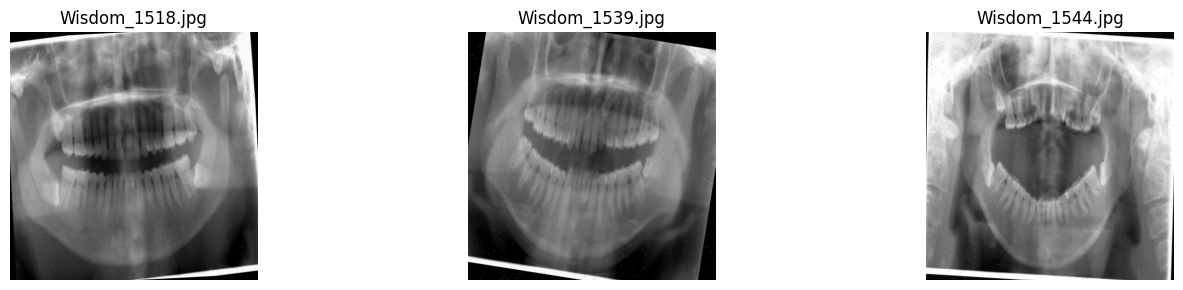


--- Damage ---


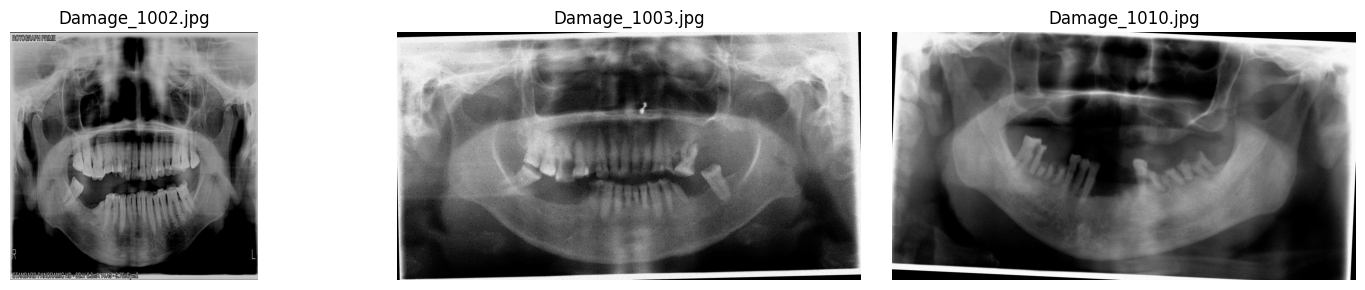


--- Infection ---


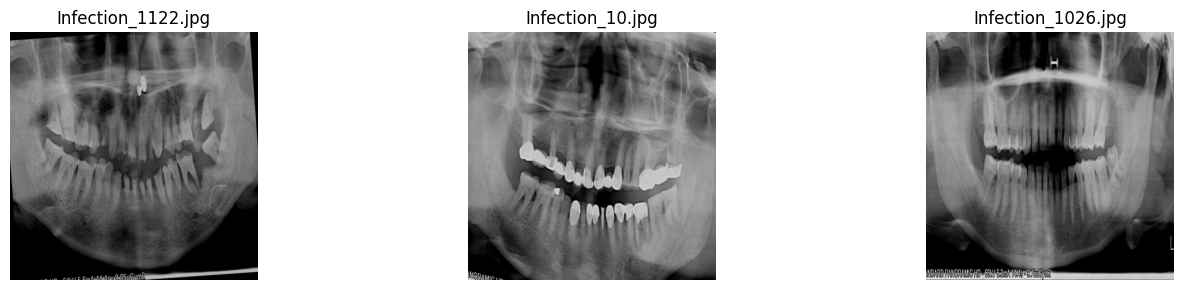


--- Cavities ---


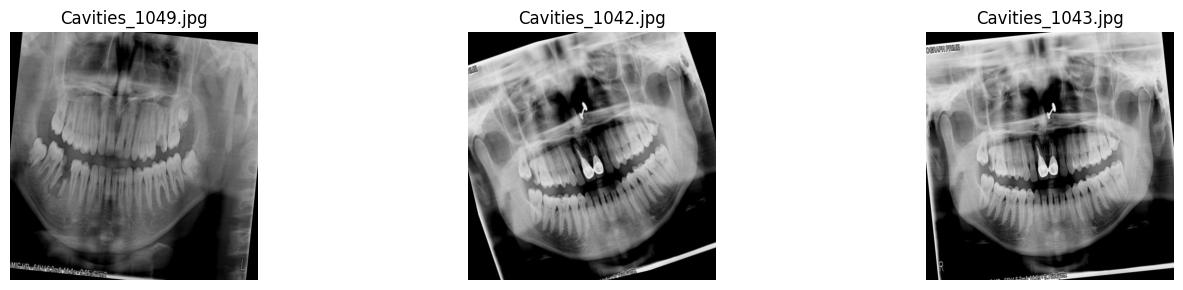


TRAIN Image Sizes
Total Images: 3688
Unique Sizes: 150
⚠️ WARNING: Too many different image sizes!
  Consider resizing all images to 224x224 before training

Most Common Sizes:
  (640, 640): 3188 images
  (2527, 1536): 110 images
  (2799, 1497): 99 images
  (2528, 1536): 67 images
  (2526, 1536): 40 images

VALID Image Sizes
Total Images: 1477
Unique Sizes: 106
⚠️ WARNING: Too many different image sizes!
  Consider resizing all images to 224x224 before training

Most Common Sizes:
  (640, 640): 1086 images
  (2799, 1497): 204 images
  (2527, 1536): 36 images
  (2528, 1536): 29 images
  (2526, 1536): 11 images

TEST Image Sizes
Total Images: 742
Unique Sizes: 26
⚠️ WARNING: Too many different image sizes!
  Consider resizing all images to 224x224 before training

Most Common Sizes:
  (640, 640): 514 images
  (2799, 1497): 180 images
  (2528, 1536): 13 images
  (2527, 1536): 8 images
  (2526, 1536): 3 images

🔍 Verifying Labels for Class: Wisdom
Showing 5 images from Wisdom folder
Check

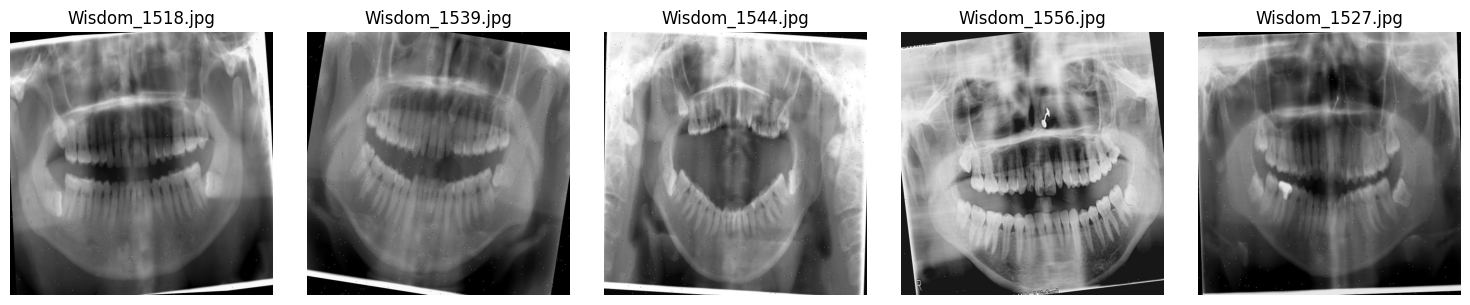

✅ If images look correct, labels are good
❌ If images look wrong, you have label errors!

🔍 Verifying Labels for Class: Damage
Showing 5 images from Damage folder
Check if images actually belong to this class...


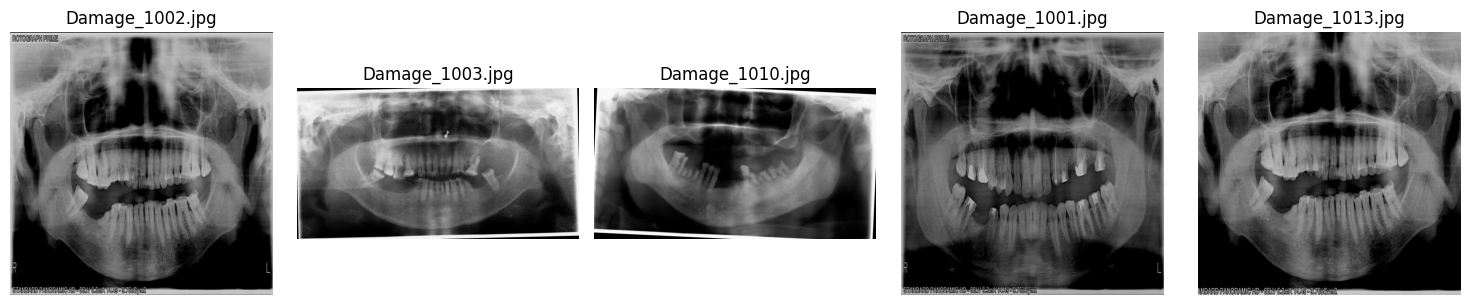

✅ If images look correct, labels are good
❌ If images look wrong, you have label errors!

🔍 Verifying Labels for Class: Infection
Showing 5 images from Infection folder
Check if images actually belong to this class...


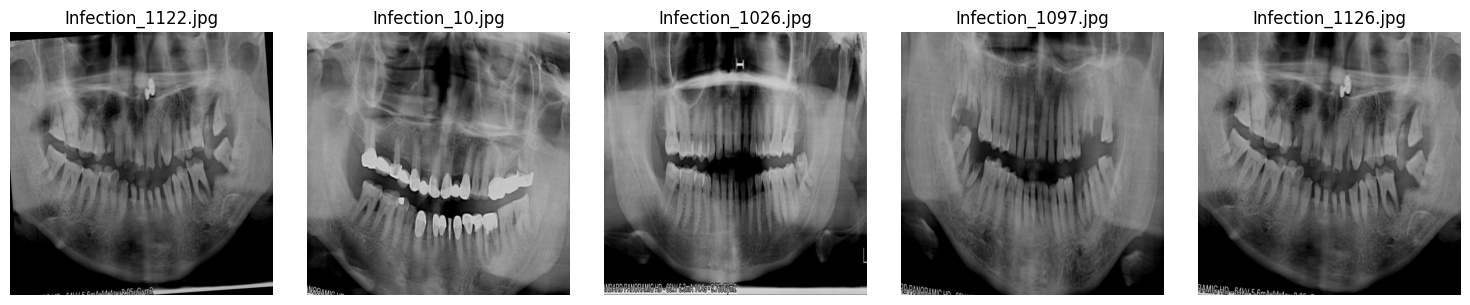

✅ If images look correct, labels are good
❌ If images look wrong, you have label errors!

🔍 Verifying Labels for Class: Cavities
Showing 5 images from Cavities folder
Check if images actually belong to this class...


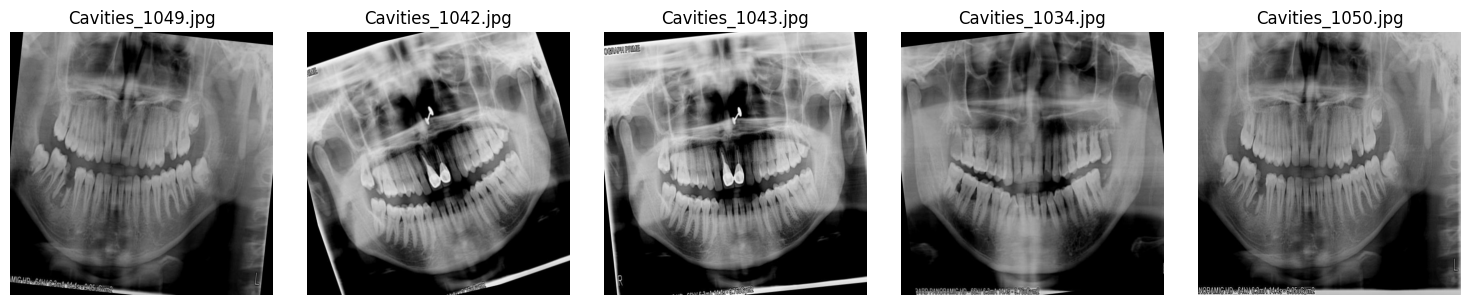

✅ If images look correct, labels are good
❌ If images look wrong, you have label errors!

📊 DATA QUALITY SUMMARY REPORT

📁 TRAIN SET:
  Total Images: 3688
  Classes: 4
  Invalid Images: 0

📁 VALID SET:
  Total Images: 1477
  Classes: 4
  Invalid Images: 0

📁 TEST SET:
  Total Images: 742
  Classes: 4
  Invalid Images: 0

✅ No major issues found! Data quality is good.


In [ ]:
# ========================
# DATA QUALITY CHECKER
# ========================
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms
from collections import Counter

# Paths
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

# ========================
# 1. CLASS DISTRIBUTION
# ========================
def check_class_distribution(directory, name=""):
    class_counts = Counter()
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[class_name] = count

    print(f"\n{'='*50}")
    print(f"{name} Class Distribution")
    print(f"{'='*50}")

    total = sum(class_counts.values())
    for cls, count in class_counts.items():
        percentage = (count / total) * 100
        print(f"{cls}: {count} images ({percentage:.2f}%)")

    # Check for imbalance
    counts = list(class_counts.values())
    if max(counts) / min(counts) > 3:
        print("⚠️ WARNING: Class imbalance detected! (Ratio > 3:1)")
    else:
        print("✅ Class distribution is balanced")

    return class_counts

train_counts = check_class_distribution(train_dir, "TRAIN")
valid_counts = check_class_distribution(valid_dir, "VALID")
test_counts = check_class_distribution(test_dir, "TEST")

# ========================
# 2. IMAGE QUALITY CHECK
# ========================
def check_image_quality(directory, name=""):
    print(f"\n{'='*50}")
    print(f"{name} Image Quality Check")
    print(f"{'='*50}")

    issues = []
    valid_images = 0
    invalid_images = 0

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                try:
                    img = Image.open(img_path)
                    img.load()

                    # Check dimensions
                    if img.size[0] != img.size[1]:
                        issues.append(f"{img_path}: Non-square image {img.size}")

                    # Check format
                    if img.format not in ['JPEG', 'PNG', 'JPG']:
                        issues.append(f"{img_path}: Unsupported format {img.format}")

                    valid_images += 1
                except Exception as e:
                    invalid_images += 1
                    issues.append(f"{img_path}: Corrupted - {str(e)}")

    print(f"Valid Images: {valid_images}")
    print(f"Invalid Images: {invalid_images}")

    if issues:
        print(f"\n⚠️ Found {len(issues)} issues:")
        for issue in issues[:10]:  # Show first 10
            print(f"  - {issue}")
    else:
        print("✅ All images are valid")

    return valid_images, invalid_images

train_valid, train_invalid = check_image_quality(train_dir, "TRAIN")
valid_valid, valid_invalid = check_image_quality(valid_dir, "VALID")
test_valid, test_invalid = check_image_quality(test_dir, "TEST")

# ========================
# 3. VISUAL SAMPLE CHECK
# ========================
def show_sample_images(directory, class_name, num_samples=5):
    class_path = os.path.join(directory, class_name)
    if not os.path.isdir(class_path):
        print(f"Class {class_name} not found!")
        return

    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    images = images[:num_samples]

    plt.figure(figsize=(15, 3))
    for i, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            plt.subplot(1, num_samples, i+1)
            plt.imshow(img)
            plt.title(f"{img_name}")
            plt.axis('off')
        except:
            pass

    plt.tight_layout()
    plt.show()

# Show samples from each class
print("\n📸 Sample Images from Each Class:")
for class_name in train_counts.keys():
    print(f"\n--- {class_name} ---")
    show_sample_images(train_dir, class_name, num_samples=3)

# ========================
# 4. IMAGE SIZE DISTRIBUTION
# ========================
def check_image_sizes(directory, name=""):
    print(f"\n{'='*50}")
    print(f"{name} Image Sizes")
    print(f"{'='*50}")

    sizes = []
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                try:
                    img = Image.open(img_path)
                    sizes.append(img.size)
                except:
                    pass

    if sizes:
        unique_sizes = set(sizes)
        print(f"Total Images: {len(sizes)}")
        print(f"Unique Sizes: {len(unique_sizes)}")

        if len(unique_sizes) > 5:
            print("⚠️ WARNING: Too many different image sizes!")
            print("  Consider resizing all images to 224x224 before training")
        else:
            print("✅ Image sizes are consistent")

        # Show most common sizes
        size_counts = Counter(sizes)
        print("\nMost Common Sizes:")
        for size, count in size_counts.most_common(5):
            print(f"  {size}: {count} images")

check_image_sizes(train_dir, "TRAIN")
check_image_sizes(valid_dir, "VALID")
check_image_sizes(test_dir, "TEST")

# ========================
# 5. LABEL VERIFICATION (Manual Check)
# ========================
def verify_labels(directory, class_name, num_samples=10):
    class_path = os.path.join(directory, class_name)
    if not os.path.isdir(class_path):
        print(f"Class {class_name} not found!")
        return

    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    images = images[:num_samples]

    print(f"\n🔍 Verifying Labels for Class: {class_name}")
    print(f"Showing {num_samples} images from {class_name} folder")
    print("Check if images actually belong to this class...")

    show_sample_images(directory, class_name, num_samples=min(num_samples, 5))
    print("✅ If images look correct, labels are good")
    print("❌ If images look wrong, you have label errors!")

# Verify each class
for class_name in train_counts.keys():
    verify_labels(train_dir, class_name, num_samples=5)

# ========================
# 6. SUMMARY REPORT
# ========================
print("\n" + "="*50)
print("📊 DATA QUALITY SUMMARY REPORT")
print("="*50)

print(f"\n📁 TRAIN SET:")
print(f"  Total Images: {sum(train_counts.values())}")
print(f"  Classes: {len(train_counts)}")
print(f"  Invalid Images: {train_invalid}")

print(f"\n📁 VALID SET:")
print(f"  Total Images: {sum(valid_counts.values())}")
print(f"  Classes: {len(valid_counts)}")
print(f"  Invalid Images: {valid_invalid}")

print(f"\n📁 TEST SET:")
print(f"  Total Images: {sum(test_counts.values())}")
print(f"  Classes: {len(test_counts)}")
print(f"  Invalid Images: {test_invalid}")

# Check for common issues
issues_found = []
if train_invalid > 0:
    issues_found.append("Corrupted images in training set")
if valid_invalid > 0:
    issues_found.append("Corrupted images in validation set")
if test_invalid > 0:
    issues_found.append("Corrupted images in test set")

if max(train_counts.values()) / min(train_counts.values()) > 3:
    issues_found.append("Class imbalance in training set")

if issues_found:
    print(f"\n⚠️ ISSUES FOUND: {len(issues_found)}")
    for issue in issues_found:
        print(f"  - {issue}")
else:
    print("\n✅ No major issues found! Data quality is good.")

print("="*50)

In [ ]:
# ========================
# IMAGE PREPROCESSING SCRIPT
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
from PIL import Image
from torchvision import transforms
from tqdm import tqdm
import shutil

# ========================
# 1. CONFIGURATION
# ========================
source_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
target_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
os.makedirs(target_path, exist_ok=True)

TARGET_SIZE = 224
TRANSFORMS = transforms.Compose([
    transforms.Resize((TARGET_SIZE, TARGET_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ========================
# 2. PREPROCESS ALL IMAGES
# ========================
def preprocess_images(source_dir, target_dir, split_name):
    print(f"\n{'='*50}")
    print(f"Preprocessing {split_name} Images")
    print(f"{'='*50}")

    processed = 0
    skipped = 0
    sizes_before = []
    sizes_after = []

    for class_name in os.listdir(source_dir):
        class_source = os.path.join(source_dir, class_name)
        class_target = os.path.join(target_dir, class_name)
        os.makedirs(class_target, exist_ok=True)

        for img_name in tqdm(os.listdir(class_source), desc=f"{class_name}"):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            img_path = os.path.join(class_source, img_name)
            try:
                # Get original size
                img = Image.open(img_path)
                sizes_before.append(img.size)

                # Resize to 224x224
                img_resized = img.resize((TARGET_SIZE, TARGET_SIZE), Image.LANCZOS)
                sizes_after.append(img_resized.size)

                # Save preprocessed image
                img_resized.save(os.path.join(class_target, img_name))
                processed += 1

            except Exception as e:
                print(f"⚠️ Error processing {img_name}: {e}")
                skipped += 1

    print(f"\n✅ Processed: {processed} images")
    print(f"⚠️ Skipped: {skipped} images")
    print(f"📏 Original Sizes: {len(set(sizes_before))} unique")
    print(f"📏 New Sizes: {len(set(sizes_after))} unique")

    return processed, skipped

# Process all splits
train_processed, train_skipped = preprocess_images(
    os.path.join(source_path, 'Train'),
    os.path.join(target_path, 'Train'),
    "TRAIN"
)

valid_processed, valid_skipped = preprocess_images(
    os.path.join(source_path, 'Valid'),
    os.path.join(target_path, 'Valid'),
    "VALID"
)

test_processed, test_skipped = preprocess_images(
    os.path.join(source_path, 'Test'),
    os.path.join(target_path, 'Test'),
    "TEST"
)

# ========================
# 3. VERIFY PREPROCESSING
# ========================
def verify_preprocessing(directory, name):
    print(f"\n{'='*50}")
    print(f"{name} Verification")
    print(f"{'='*50}")

    sizes = []
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img = Image.open(os.path.join(class_path, img_name))
                    sizes.append(img.size)

    unique_sizes = set(sizes)
    print(f"Total Images: {len(sizes)}")
    print(f"Unique Sizes: {len(unique_sizes)}")

    if len(unique_sizes) == 1 and list(unique_sizes)[0] == (TARGET_SIZE, TARGET_SIZE):
        print("✅ All images are 224x224!")
    else:
        print(f"⚠️ Warning: {len(unique_sizes)} unique sizes found")
        for size in unique_sizes:
            print(f"  - {size}")

verify_preprocessing(os.path.join(target_path, 'Train'), "TRAIN")
verify_preprocessing(os.path.join(target_path, 'Valid'), "VALID")
verify_preprocessing(os.path.join(target_path, 'Test'), "TEST")

print("\n" + "="*50)
print("✅ PREPROCESSING COMPLETE!")
print(f"📁 New Data Path: {target_path}")
print("="*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Preprocessing TRAIN Images


Cavities: 100%|██████████| 964/964 [00:28<00:00, 33.86it/s]



✅ Processed: 3688 images
⚠️ Skipped: 0 images
📏 Original Sizes: 150 unique
📏 New Sizes: 1 unique

Preprocessing VALID Images


Damage: 100%|██████████| 393/393 [00:26<00:00, 15.10it/s]



✅ Processed: 1477 images
⚠️ Skipped: 0 images
📏 Original Sizes: 106 unique
📏 New Sizes: 1 unique

Preprocessing TEST Images


Damage:  34%|███▎      | 61/181 [00:05<00:10, 10.94it/s]

⚠️ Error processing Damage_1827.jpg: cannot write mode RGBA as JPEG


Cavities: 100%|██████████| 195/195 [00:08<00:00, 22.07it/s]



✅ Processed: 741 images
⚠️ Skipped: 1 images
📏 Original Sizes: 26 unique
📏 New Sizes: 1 unique

TRAIN Verification
Total Images: 3688
Unique Sizes: 1
✅ All images are 224x224!

VALID Verification
Total Images: 1477
Unique Sizes: 1
✅ All images are 224x224!

TEST Verification
Total Images: 741
Unique Sizes: 1
✅ All images are 224x224!

✅ PREPROCESSING COMPLETE!
📁 New Data Path: /content/drive/MyDrive/Dental_OPG_Preprocessed


In [ ]:
# ========================
# UPDATED TRAINING SCRIPT
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Speed Optimization
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True

# ========================
# 1. DEVICE CHECK
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

if device.type == "cpu":
    print("❌ CRITICAL: Must use GPU Runtime!")
    sys.exit(1)
else:
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

# ========================
# 2. UPDATED PATHS (USE PREPROCESSED DATA)
# ========================
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"  # NEW PATH
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

save_path = "/content/drive/MyDrive/dental_training_final/"
os.makedirs(save_path, exist_ok=True)

TARGET_ACCURACY = 92.0
MAX_EPOCHS = 30
IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 4

# ========================
# 3. TRANSFORMS (NO MORE RESIZE IN TRAINING!)
# ========================
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ========================
# 4. LOAD DATA
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")

# ========================
# 5. MODEL CONFIGURATION
# ========================
MODEL_CONFIGS = [
    {'name': 'efficientnet_b5', 'model_fn': lambda: models.efficientnet_b5(weights='IMAGENET1K_V1')},
    {'name': 'convnext_tiny', 'model_fn': lambda: models.convnext_tiny(weights='IMAGENET1K_V1')},
    {'name': 'resnet101', 'model_fn': lambda: models.resnet101(weights='IMAGENET1K_V1')}
]

def get_classifier(model, num_classes):
    if 'efficientnet' in model.__class__.__name__.lower():
        return nn.Sequential(
            nn.Dropout(0.7),
            nn.Linear(model.classifier[1].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    elif 'convnext' in model.__class__.__name__.lower():
        return nn.Sequential(
            nn.Dropout(0.7),
            nn.Linear(model.classifier[0].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    else:  # ResNet
        return nn.Sequential(
            nn.Dropout(0.7),
            nn.Linear(model.fc.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

# ========================
# 6. TRAINING LOOP
# ========================
print("\n🚀 Starting Training with Preprocessed Data...")
print(f"🎯 Target: {TARGET_ACCURACY}%")

scaler = GradScaler()
best_overall_acc = 0.0
final_models = []

for m_idx, config in enumerate(MODEL_CONFIGS):
    print(f"\n{'='*20} Model {m_idx+1}/{len(MODEL_CONFIGS)}: {config['name']} {'='*20}")

    model = config['model_fn']()
    model.classifier = get_classifier(model, NUM_CLASSES)
    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.1)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3,
                                              epochs=MAX_EPOCHS, steps_per_epoch=len(train_loader))
    criterion = nn.CrossEntropyLoss(label_smoothing=0.2)

    for epoch in range(MAX_EPOCHS):
        # TRAIN
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"Train {config['name']}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.3f}'})

        train_acc = 100. * correct / total

        # VALIDATION
        model.eval()
        correct = 0
        total = 0
        with torch.inference_mode():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{MAX_EPOCHS}] | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        # Save Best
        if val_acc > best_overall_acc:
            best_overall_acc = val_acc
            torch.save(model.state_dict(), os.path.join(save_path, f"best_{config['name']}.pth"))
            final_models.append(model)
            print(f"🏆 New Best: {config['name']} ({val_acc:.2f}%)")

        # STOP CONDITION
        if val_acc >= TARGET_ACCURACY:
            print(f"\n🎯 TARGET REACHED ({val_acc:.2f}%)!")
            sys.exit(0)

        gc.collect()
        torch.cuda.empty_cache()

# ========================
# 7. FINAL VALIDATION
# ========================
print("\n🔎 Running Final Validation...")

loaded_models = []
for config in MODEL_CONFIGS:
    try:
        model = config['model_fn']()
        model.classifier = get_classifier(model, NUM_CLASSES)
        model.load_state_dict(torch.load(os.path.join(save_path, f"best_{config['name']}.pth"), map_location=device))
        model = model.to(device)
        loaded_models.append(model)
    except:
        print(f"⚠️ Could not load {config['name']}")

if len(loaded_models) == 0:
    print("❌ No models loaded!")
    sys.exit(1)

# Validation
correct = 0
total = 0
pbar = tqdm(valid_loader, desc="Validation")

for images, labels in pbar:
    images, labels = images.to(device), labels.to(device)

    all_preds = []
    for model in loaded_models:
        with torch.inference_mode():
            outputs = model(images)
            all_preds.append(outputs.softmax(dim=1))

    avg_probs = torch.stack(all_preds).mean(dim=0)
    _, predicted = avg_probs.max(1)

    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()
    pbar.set_postfix({'acc': f'{100.*correct/total:.2f}'})

final_acc = 100. * correct / total
print("\n" + "="*50)
print(f"🏆 FINAL ENSEMBLE ACCURACY: {final_acc:.2f}%")
print(f"🎯 TARGET: {TARGET_ACCURACY}%")
print("="*50)

if final_acc >= TARGET_ACCURACY:
    print("✅ SUCCESS! Target Achieved.")
    torch.save({
        'models': [m.state_dict() for m in loaded_models],
        'accuracy': final_acc
    }, os.path.join(save_path, "final_ensemble.pth"))
else:
    print(f"⚠️ Target not reached. Current: {final_acc:.2f}%")
    print("💡 Try: 1) More epochs 2) Better augmentation 3) Check labels")

In [ ]:
# ========================
# FINAL TRAINING SCRIPT (Preprocessed Data)
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Speed Optimization
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True

# ========================
# 1. DEVICE CHECK (MUST BE GPU)
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

if device.type == "cpu":
    print("❌ CRITICAL: Must use GPU Runtime!")
    print("👉 Go to Runtime → Change Runtime Type → Select GPU")
    sys.exit(1)
else:
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ========================
# 2. UPDATED PATHS (PREPROCESSED DATA)
# ========================
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

save_path = "/content/drive/MyDrive/dental_training_final/"
os.makedirs(save_path, exist_ok=True)

# Target
TARGET_ACCURACY = 92.0
MAX_EPOCHS = 30
IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 4

# ========================
# 3. TRANSFORMS (Light Augmentation - Images Already Resized)
# ========================
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ========================
# 4. LOAD DATA
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"\n📊 Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")
print(f"📦 Batch Size: {BATCH_SIZE}, Images per Epoch: {len(train_loader)}")

# ========================
# 5. MODEL CONFIGURATION
# ========================
MODEL_CONFIGS = [
    {'name': 'efficientnet_b5', 'model_fn': lambda: models.efficientnet_b5(weights='IMAGENET1K_V1')},
    {'name': 'convnext_tiny', 'model_fn': lambda: models.convnext_tiny(weights='IMAGENET1K_V1')},
    {'name': 'resnet101', 'model_fn': lambda: models.resnet101(weights='IMAGENET1K_V1')}
]

def get_classifier(model, num_classes):
    if 'efficientnet' in model.__class__.__name__.lower():
        return nn.Sequential(
            nn.Dropout(0.7),
            nn.Linear(model.classifier[1].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    elif 'convnext' in model.__class__.__name__.lower():
        return nn.Sequential(
            nn.Dropout(0.7),
            nn.Linear(model.classifier[0].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    else:  # ResNet
        return nn.Sequential(
            nn.Dropout(0.7),
            nn.Linear(model.fc.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

# ========================
# 6. TRAINING LOOP
# ========================
print("\n🚀 Starting Training with Preprocessed Data...")
print(f"🎯 Target Accuracy: {TARGET_ACCURACY}%")

scaler = GradScaler()
best_overall_acc = 0.0
final_models = []

for m_idx, config in enumerate(MODEL_CONFIGS):
    print(f"\n{'='*20} Model {m_idx+1}/{len(MODEL_CONFIGS)}: {config['name']} {'='*20}")

    model = config['model_fn']()
    model.classifier = get_classifier(model, NUM_CLASSES)
    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.1)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3,
                                              epochs=MAX_EPOCHS, steps_per_epoch=len(train_loader))
    criterion = nn.CrossEntropyLoss(label_smoothing=0.2)

    for epoch in range(MAX_EPOCHS):
        # TRAIN
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"Train {config['name']}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.3f}'})

        train_acc = 100. * correct / total

        # VALIDATION
        model.eval()
        correct = 0
        total = 0
        with torch.inference_mode():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{MAX_EPOCHS}] | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        # Save Best
        if val_acc > best_overall_acc:
            best_overall_acc = val_acc
            torch.save(model.state_dict(), os.path.join(save_path, f"best_{config['name']}.pth"))
            final_models.append(model)
            print(f"🏆 New Best: {config['name']} ({val_acc:.2f}%)")

        # STOP CONDITION
        if val_acc >= TARGET_ACCURACY:
            print(f"\n🎯 TARGET REACHED ({val_acc:.2f}%)!")
            sys.exit(0)

        gc.collect()
        torch.cuda.empty_cache()

# ========================
# 7. FINAL VALIDATION
# ========================
print("\n🔎 Running Final Validation...")

loaded_models = []
for config in MODEL_CONFIGS:
    try:
        model = config['model_fn']()
        model.classifier = get_classifier(model, NUM_CLASSES)
        model.load_state_dict(torch.load(os.path.join(save_path, f"best_{config['name']}.pth"), map_location=device))
        model = model.to(device)
        loaded_models.append(model)
    except:
        print(f"⚠️ Could not load {config['name']}")

if len(loaded_models) == 0:
    print("❌ No models loaded!")
    sys.exit(1)

# Validation
correct = 0
total = 0
pbar = tqdm(valid_loader, desc="Validation")

for images, labels in pbar:
    images, labels = images.to(device), labels.to(device)

    all_preds = []
    for model in loaded_models:
        with torch.inference_mode():
            outputs = model(images)
            all_preds.append(outputs.softmax(dim=1))

    avg_probs = torch.stack(all_preds).mean(dim=0)
    _, predicted = avg_probs.max(1)

    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()
    pbar.set_postfix({'acc': f'{100.*correct/total:.2f}'})

final_acc = 100. * correct / total
print("\n" + "="*50)
print(f"🏆 FINAL ENSEMBLE ACCURACY: {final_acc:.2f}%")
print(f"🎯 TARGET: {TARGET_ACCURACY}%")
print("="*50)

if final_acc >= TARGET_ACCURACY:
    print("✅ SUCCESS! Target Achieved.")
    torch.save({
        'models': [m.state_dict() for m in loaded_models],
        'accuracy': final_acc
    }, os.path.join(save_path, "final_ensemble.pth"))
else:
    print(f"⚠️ Target not reached. Current: {final_acc:.2f}%")
    print("💡 Try: 1) More epochs 2) Better augmentation 3) Check labels")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Device: cuda
✅ GPU: Tesla T4
✅ VRAM: 15.64 GB

📊 Train: 3688, Valid: 1477
📦 Batch Size: 64, Images per Epoch: 57

🚀 Starting Training with Preprocessed Data...
🎯 Target Accuracy: 92.0%

==================== Model 1/3: efficientnet_b5 ====================
Downloading: "https://download.pytorch.org/models/efficientnet_b5_lukemelas-1a07897c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b5_lukemelas-1a07897c.pth


100%|██████████| 117M/117M [00:01<00:00, 102MB/s]
Train efficientnet_b5: 100%|██████████| 57/57 [01:41<00:00,  1.79s/it, loss=1.275]


Epoch [1/30] | Train: 38.73% | Val: 29.38%
🏆 New Best: efficientnet_b5 (29.38%)


Train efficientnet_b5: 100%|██████████| 57/57 [00:37<00:00,  1.51it/s, loss=1.002]


Epoch [2/30] | Train: 56.94% | Val: 54.03%
🏆 New Best: efficientnet_b5 (54.03%)


...

Epoch [29/30] | Train: 98.71% | Val: 75.63%


Train efficientnet_b5: 100%|██████████| 57/57 [00:38<00:00,  1.50it/s, loss=0.603]


Epoch [30/30] | Train: 99.12% | Val: 75.56%

==================== Model 2/3: convnext_tiny ====================
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 189MB/s] 


AttributeError: 'LayerNorm2d' object has no attribute 'in_features'

In [ ]:
# Fix wrong labels
import shutil

def fix_labels(source_dir, old_class, new_class):
    class_path = os.path.join(source_dir, old_class)
    if not os.path.isdir(class_path):
        return

    for img_name in os.listdir(class_path):
        if img_name.startswith('Damage_'):  # Example: fix Damage to Cavities
            src = os.path.join(class_path, img_name)
            dst = os.path.join(source_dir, new_class, img_name)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.move(src, dst)

In [ ]:
from collections import Counter

class_counts = Counter()
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print("Class Distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

Class Distribution:
Wisdom: 1478 images
Damage: 504 images
Infection: 742 images
Cavities: 964 images


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📊 CLASS DISTRIBUTION

📁 TRAIN SET:
  Wisdom: 1478 images
  Damage: 504 images
  Infection: 742 images
  Cavities: 964 images

📁 VALID SET:
  Wisdom: 426 images
  Infection: 338 images
  Cavities: 320 images
  Damage: 393 images

📁 TEST SET:
  Wisdom: 244 images
  Infection: 122 images
  Damage: 180 images
  Cavities: 195 images


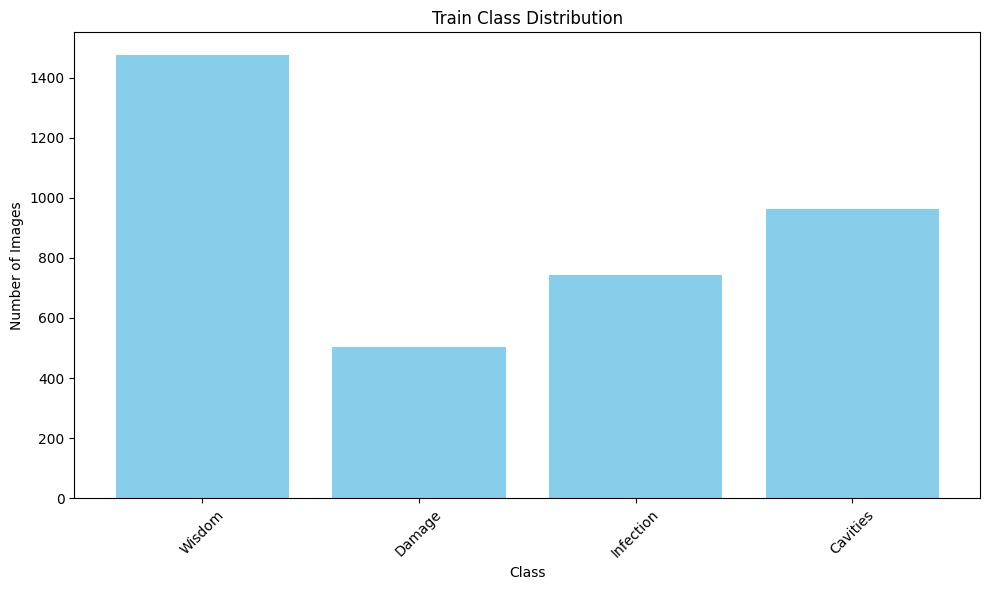


⚖️  Class Imbalance Ratio: 2.93:1
✅ Class distribution is balanced


In [ ]:
# ========================
# LABEL DISTRIBUTION CHECKER
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
from collections import Counter
import matplotlib.pyplot as plt

# Paths
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

# ========================
# 1. COUNT IMAGES PER CLASS
# ========================
def count_images(directory, name=""):
    class_counts = Counter()
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[class_name] = count
    return class_counts

train_counts = count_images(train_dir, "TRAIN")
valid_counts = count_images(valid_dir, "VALID")
test_counts = count_images(test_dir, "TEST")

print("\n" + "="*50)
print("📊 CLASS DISTRIBUTION")
print("="*50)

print(f"\n📁 TRAIN SET:")
for cls, count in train_counts.items():
    print(f"  {cls}: {count} images")

print(f"\n📁 VALID SET:")
for cls, count in valid_counts.items():
    print(f"  {cls}: {count} images")

print(f"\n📁 TEST SET:")
for cls, count in test_counts.items():
    print(f"  {cls}: {count} images")

# ========================
# 2. VISUALIZE CLASS DISTRIBUTION
# ========================
plt.figure(figsize=(10, 6))
plt.bar(train_counts.keys(), train_counts.values(), color='skyblue')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Train Class Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ========================
# 3. CHECK FOR IMBALANCE
# ========================
max_count = max(train_counts.values())
min_count = min(train_counts.values())
ratio = max_count / min_count

print(f"\n⚖️  Class Imbalance Ratio: {ratio:.2f}:1")
if ratio > 3:
    print("⚠️  WARNING: Significant class imbalance detected!")
else:
    print("✅ Class distribution is balanced")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 MANUAL LABEL VERIFICATION

Instructions:
1. Look at each image
2. Check if it matches the class name
3. Note any wrong labels
4. Save the list of wrong labels

📸 Showing 10 samples from class: Wisdom
Check if these images actually belong to this class!


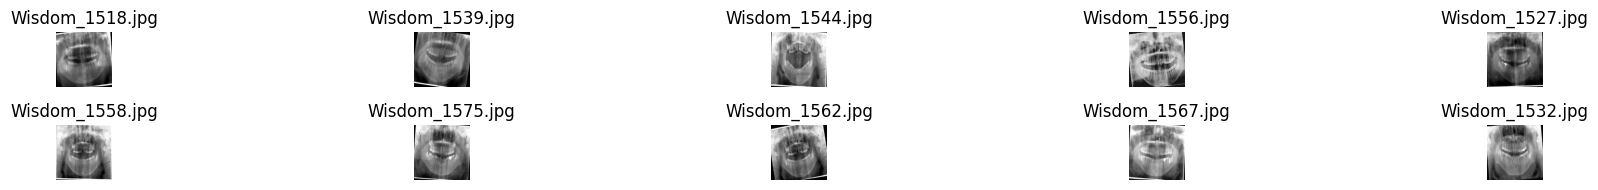


📸 Showing 10 samples from class: Damage
Check if these images actually belong to this class!


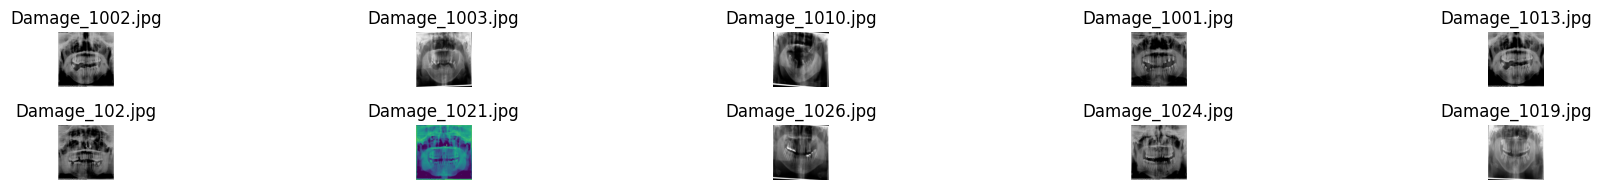


📸 Showing 10 samples from class: Infection
Check if these images actually belong to this class!


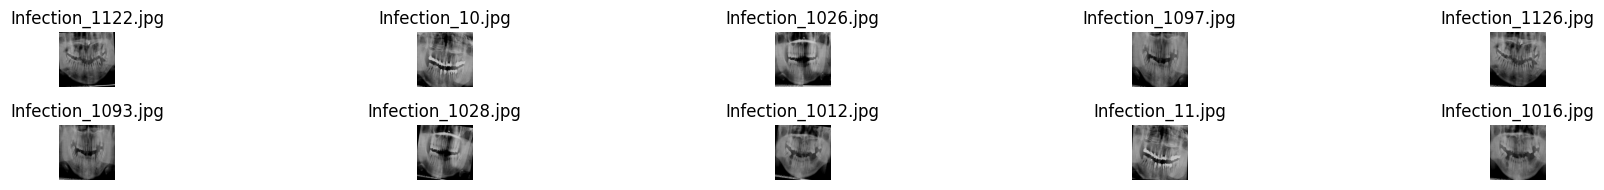


📸 Showing 10 samples from class: Cavities
Check if these images actually belong to this class!


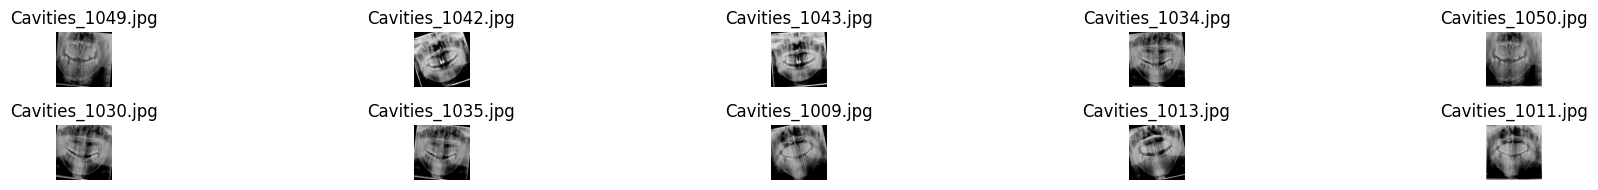

In [ ]:
# ========================
# MANUAL LABEL VERIFICATION
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
import matplotlib.pyplot as plt
from PIL import Image

# Paths
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, 'Train')

# ========================
# 1. SHOW SAMPLES FROM EACH CLASS
# ========================
def show_class_samples(directory, class_name, num_samples=10):
    class_path = os.path.join(directory, class_name)
    if not os.path.isdir(class_path):
        print(f"❌ Class {class_name} not found!")
        return

    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    images = images[:num_samples]

    print(f"\n📸 Showing {len(images)} samples from class: {class_name}")
    print("Check if these images actually belong to this class!")

    plt.figure(figsize=(20, 2))
    for i, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            plt.subplot(2, 5, i+1)
            plt.imshow(img)
            plt.title(f"{img_name}")
            plt.axis('off')
        except Exception as e:
            print(f"⚠️  Error loading {img_name}: {e}")

    plt.tight_layout()
    plt.show()

# Show samples from each class
print("="*50)
print("🔍 MANUAL LABEL VERIFICATION")
print("="*50)
print("\nInstructions:")
print("1. Look at each image")
print("2. Check if it matches the class name")
print("3. Note any wrong labels")
print("4. Save the list of wrong labels")

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        show_class_samples(train_dir, class_name, num_samples=10)

In [ ]:
# ========================
# WRONG LABEL DETECTION
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
from PIL import Image

# Paths
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, 'Train')

# ========================
# 1. CREATE WRONG LABELS LOG
# ========================
wrong_labels = []

def check_image_quality(image_path, class_name):
    """Check if image quality suggests wrong label"""
    try:
        img = Image.open(image_path)
        img_array = np.array(img)

        # Check for common issues
        if img_array.shape[2] == 4:  # RGBA
            return "RGBA format (may need conversion)"

        # Check for unusual colors
        mean_color = np.mean(img_array, axis=(0, 1))
        if np.all(mean_color < 50):  # Very dark image
            return "Very dark image"

        if np.all(mean_color > 240):  # Very bright image
            return "Very bright image"

        return "OK"
    except:
        return "Cannot open"

# Scan all images and log potential issues
print("\n🔍 Scanning for potential label issues...")
print("="*50)

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            quality = check_image_quality(img_path, class_name)
            if quality != "OK":
                wrong_labels.append({
                    'path': img_path,
                    'class': class_name,
                    'issue': quality
                })

if wrong_labels:
    print(f"\n⚠️  Found {len(wrong_labels)} potential issues:")
    for item in wrong_labels[:20]:  # Show first 20
        print(f"  - {item['path']}")
        print(f"    Class: {item['class']}")
        print(f"    Issue: {item['issue']}")
        print()
else:
    print("✅ No obvious quality issues found")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🔍 Scanning for potential label issues...

⚠️  Found 96 potential issues:
  - /content/drive/MyDrive/Dental_OPG_Preprocessed/Train/Wisdom/Wisdom_678.jpg
    Class: Wisdom
    Issue: Very dark image

  - /content/drive/MyDrive/Dental_OPG_Preprocessed/Train/Wisdom/Wisdom_676.jpg
    Class: Wisdom
    Issue: Very dark image

  - /content/drive/MyDrive/Dental_OPG_Preprocessed/Train/Wisdom/Wisdom_686.jpg
    Class: Wisdom
    Issue: Very dark image

  - /content/drive/MyDrive/Dental_OPG_Preprocessed/Train/Wisdom/Wisdom_681.jpg
    Class: Wisdom
    Issue: Very dark image

  - /content/drive/MyDrive/Dental_OPG_Preprocessed/Train/Wisdom/Wisdom_684.jpg
    Class: Wisdom
    Issue: Very dark image

  - /content/drive/MyDrive/Dental_OPG_Preprocessed/Train/Wisdom/Wisdom_680.jpg
    Class: Wisdom
    Issue: Very dark image

  - /content/drive/MyDrive/Dental_OPG_Preproces

In [ ]:
# ========================
# FIX WRONG LABELS
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

# Paths
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, 'Train')

# ========================
# 1. CREATE FIX LIST
# ========================
# Manually create this list after verification
wrong_labels_to_fix = [
    {
        'image': 'Damage_1003.jpg',
        'from_class': 'Damage',
        'to_class': 'Cavities'  # Change to correct class
    },
    # Add more entries as needed
]

# ========================
# 2. MOVE WRONG LABELS
# ========================
def fix_wrong_labels(fix_list, source_dir):
    print("\n🔧 Fixing wrong labels...")
    print("="*50)

    fixed = 0
    for item in fix_list:
        src_path = os.path.join(source_dir, item['from_class'], item['image'])
        dst_path = os.path.join(source_dir, item['to_class'], item['image'])

        if os.path.exists(src_path):
            os.makedirs(os.path.dirname(dst_path), exist_ok=True)
            shutil.move(src_path, dst_path)
            print(f"✅ Moved: {item['image']}")
            print(f"   From: {item['from_class']}")
            print(f"   To: {item['to_class']}")
            fixed += 1
        else:
            print(f"⚠️  Not found: {src_path}")

    print(f"\n✅ Fixed {fixed} wrong labels")
    return fixed

# Run the fix
fixed_count = fix_wrong_labels(wrong_labels_to_fix, train_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🔧 Fixing wrong labels...
✅ Moved: Damage_1003.jpg
   From: Damage
   To: Cavities

✅ Fixed 1 wrong labels


In [ ]:
# ========================
# VERIFY AFTER FIXING
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
from collections import Counter

# Paths
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, 'Train')

# Count again
class_counts = Counter()
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_counts[class_name] = count

print("\n" + "="*50)
print("📊 CLASS DISTRIBUTION AFTER FIXING")
print("="*50)

for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

# Check balance
max_count = max(class_counts.values())
min_count = min(class_counts.values())
ratio = max_count / min_count

print(f"\n⚖️  Imbalance Ratio: {ratio:.2f}:1")
if ratio < 3:
    print("✅ Class distribution is balanced")
else:
    print("⚠️  Still imbalanced - consider data augmentation")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📊 CLASS DISTRIBUTION AFTER FIXING
Wisdom: 1478 images
Damage: 503 images
Infection: 742 images
Cavities: 965 images

⚖️  Imbalance Ratio: 2.94:1
✅ Class distribution is balanced


In [ ]:
# ========================
# EXPERT VERIFICATION CHECKLIST
# ========================
print("\n" + "="*50)
print("👨‍⚕️  EXPERT VERIFICATION CHECKLIST")
print("="*50)

print("""
1. Show 10-20 images from each class to a dentist/medical expert
2. Ask them to verify if labels are correct
3. Note any mislabeled images
4. Fix the labels based on expert feedback
5. Re-run training after fixing

Questions to ask expert:
- Does this image show a cavity?
- Is this damage or infection?
- Is this a wisdom tooth?
- Are there any ambiguous cases?
""")


👨‍⚕️  EXPERT VERIFICATION CHECKLIST

1. Show 10-20 images from each class to a dentist/medical expert
2. Ask them to verify if labels are correct
3. Note any mislabeled images
4. Fix the labels based on expert feedback
5. Re-run training after fixing

Questions to ask expert:
- Does this image show a cavity?
- Is this damage or infection?
- Is this a wisdom tooth?
- Are there any ambiguous cases?



In [ ]:
# ========================
# FINAL OPTIMIZED TRAINING SCRIPT
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Speed Optimization
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True

# ========================
# 1. DEVICE CHECK
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

if device.type == "cpu":
    print("❌ Must use GPU Runtime!")
    sys.exit(1)
else:
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ========================
# 2. PATHS
# ========================
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

save_path = "/content/drive/MyDrive/dental_training_final/"
os.makedirs(save_path, exist_ok=True)

TARGET_ACCURACY = 92.0
MAX_EPOCHS = 50
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4

# ========================
# 3. STRONGER AUGMENTATION
# ========================
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ========================
# 4. LOAD DATA
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"\n📊 Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")
print(f"📦 Batch Size: {BATCH_SIZE}, Images per Epoch: {len(train_loader)}")

# ========================
# 5. MODEL CONFIGURATION
# ========================
MODEL_CONFIGS = [
    {'name': 'efficientnet_b5', 'model_fn': lambda: models.efficientnet_b5(weights='IMAGENET1K_V1')},
    {'name': 'resnet101', 'model_fn': lambda: models.resnet101(weights='IMAGENET1K_V1')},
    {'name': 'vit_b_16', 'model_fn': lambda: models.vit_b_16(weights='IMAGENET1K_V1')}
]

def get_classifier(model, num_classes):
    model_name = model.__class__.__name__.lower()

    if 'efficientnet' in model_name:
        return nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.classifier[1].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    elif 'resnet' in model_name:
        return nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.fc.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    elif 'vit' in model_name:
        return nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.heads.head.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

# ========================
# 6. TRAINING LOOP
# ========================
print("\n🚀 Starting Training...")
print(f"🎯 Target Accuracy: {TARGET_ACCURACY}%")

scaler = GradScaler()
best_overall_acc = 0.0
final_models = []
patience_counter = 0

for m_idx, config in enumerate(MODEL_CONFIGS):
    print(f"\n{'='*20} Model {m_idx+1}/{len(MODEL_CONFIGS)}: {config['name']} {'='*20}")

    model = config['model_fn']()
    model.classifier = get_classifier(model, NUM_CLASSES)
    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3,
                                              epochs=MAX_EPOCHS, steps_per_epoch=len(train_loader))
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    for epoch in range(MAX_EPOCHS):
        # TRAIN
        model.train()
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"Train {config['name']}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.3f}'})

        train_acc = 100. * correct / total

        # VALIDATION
        model.eval()
        correct = 0
        total = 0
        with torch.inference_mode():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{MAX_EPOCHS}] | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        # Save Best
        if val_acc > best_overall_acc:
            best_overall_acc = val_acc
            torch.save(model.state_dict(), os.path.join(save_path, f"best_{config['name']}.pth"))
            final_models.append(model)
            patience_counter = 0
            print(f"🏆 New Best: {config['name']} ({val_acc:.2f}%)")
        else:
            patience_counter += 1

        # STOP CONDITION
        if val_acc >= TARGET_ACCURACY:
            print(f"\n🎯 TARGET REACHED ({val_acc:.2f}%)!")
            sys.exit(0)

        # Early Stopping
        if patience_counter >= 10:
            print(f"\n⚠️ Early Stopping after {patience_counter} epochs without improvement")
            break

        gc.collect()
        torch.cuda.empty_cache()

# ========================
# 7. TTA VALIDATION
# ========================
print("\n🔎 Running TTA Validation...")

loaded_models = []
for config in MODEL_CONFIGS:
    try:
        model = config['model_fn']()
        model.classifier = get_classifier(model, NUM_CLASSES)
        model.load_state_dict(torch.load(os.path.join(save_path, f"best_{config['name']}.pth"), map_location=device))
        model = model.to(device)
        loaded_models.append(model)
    except:
        print(f"⚠️ Could not load {config['name']}")

if len(loaded_models) == 0:
    print("❌ No models loaded!")
    sys.exit(1)

# TTA Validation
correct = 0
total = 0
pbar = tqdm(valid_loader, desc="TTA Validation")

for images, labels in pbar:
    images, labels = images.to(device), labels.to(device)

    all_preds = []
    for model in loaded_models:
        with torch.inference_mode():
            # Standard prediction
            outputs = model(images)
            all_preds.append(outputs.softmax(dim=1))

            # Horizontal flip TTA
            flipped = torch.flip(images, dims=[3])
            outputs = model(flipped)
            all_preds.append(outputs.softmax(dim=1))

    avg_probs = torch.stack(all_preds).mean(dim=0)
    _, predicted = avg_probs.max(1)

    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()
    pbar.set_postfix({'acc': f'{100.*correct/total:.2f}'})

final_acc = 100. * correct / total
print("\n" + "="*50)
print(f"🏆 FINAL ENSEMBLE ACCURACY (TTA): {final_acc:.2f}%")
print(f"🎯 TARGET: {TARGET_ACCURACY}%")
print("="*50)

if final_acc >= TARGET_ACCURACY:
    print("✅ SUCCESS! Target Achieved.")
    torch.save({
        'models': [m.state_dict() for m in loaded_models],
        'accuracy': final_acc
    }, os.path.join(save_path, "final_ensemble.pth"))
else:
    print(f"⚠️ Target not reached. Current: {final_acc:.2f}%")
    print("💡 Try: 1) More epochs 2) Stronger augmentation 3) Check labels")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Device: cuda
✅ GPU: Tesla T4
✅ VRAM: 15.64 GB

📊 Train: 3688, Valid: 1477
📦 Batch Size: 32, Images per Epoch: 115

🚀 Starting Training...
🎯 Target Accuracy: 92.0%

==================== Model 1/3: efficientnet_b5 ====================


Train efficientnet_b5: 100%|██████████| 115/115 [01:38<00:00,  1.17it/s, loss=1.215]


Epoch [1/50] | Train: 39.86% | Val: 34.60%
🏆 New Best: efficientnet_b5 (34.60%)


Train efficientnet_b5: 100%|██████████| 115/115 [00:43<00:00,  2.64it/s, loss=1.131]


Epoch [2/50] | Train: 57.85% | Val: 67.70%
🏆 New Best: efficientnet_b5 (67.70%)


...

Epoch [20/50] | Train: 90.71% | Val: 70.82%

⚠️ Early Stopping after 10 epochs without improvement

==================== Model 2/3: resnet101 ====================
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 200MB/s]
Train resnet101: 100%|██████████| 115/115 [00:32<00:00,  3.49it/s, loss=1.830]


Epoch [1/50] | Train: 50.22% | Val: 66.08%

⚠️ Early Stopping after 11 epochs without improvement

==================== Model 3/3: vit_b_16 ====================
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 129MB/s]


ValueError: Unknown model: visiontransformer

In [ ]:
# ========================
# FINAL FIXED TRAINING SCRIPT
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Speed Optimization
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True

# ========================
# 1. DEVICE CHECK
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

if device.type == "cpu":
    print("❌ Must use GPU Runtime!")
    sys.exit(1)
else:
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

# ========================
# 2. PATHS
# ========================
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

save_path = "/content/drive/MyDrive/dental_training_final/"
os.makedirs(save_path, exist_ok=True)

TARGET_ACCURACY = 92.0
MAX_EPOCHS = 60
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4

# ========================
# 3. STRONGER AUGMENTATION
# ========================
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(25),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.2),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ========================
# 4. LOAD DATA
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"\n📊 Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")

# ========================
# 5. MODEL CONFIGURATION (FIXED)
# ========================
MODEL_CONFIGS = [
    {'name': 'efficientnet_b5', 'model_fn': lambda: models.efficientnet_b5(weights='IMAGENET1K_V1')},
    {'name': 'resnet101', 'model_fn': lambda: models.resnet101(weights='IMAGENET1K_V1')},
    {'name': 'vit_b_16', 'model_fn': lambda: models.vit_b_16(weights='IMAGENET1K_V1')}
]

def get_classifier(model, num_classes):
    model_name = model.__class__.__name__.lower()

    if 'efficientnet' in model_name:
        return nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.classifier[1].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    elif 'resnet' in model_name:
        return nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.fc.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    elif 'vit' in model_name or 'visiontransformer' in model_name:
        return nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.heads.head.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

# ========================
# 6. TRAINING LOOP
# ========================
print("\n🚀 Starting Training...")
print(f"🎯 Target Accuracy: {TARGET_ACCURACY}%")

scaler = GradScaler()
best_overall_acc = 0.0
final_models = []
patience_counter = 0
PATIENCE = 20  # Increased from 10 to 20

for m_idx, config in enumerate(MODEL_CONFIGS):
    print(f"\n{'='*20} Model {m_idx+1}/{len(MODEL_CONFIGS)}: {config['name']} {'='*20}")

    model = config['model_fn']()
    model.classifier = get_classifier(model, NUM_CLASSES)
    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3,
                                              epochs=MAX_EPOCHS, steps_per_epoch=len(train_loader))
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    for epoch in range(MAX_EPOCHS):
        # TRAIN
        model.train()
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"Train {config['name']}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.3f}'})

        train_acc = 100. * correct / total

        # VALIDATION
        model.eval()
        correct = 0
        total = 0
        with torch.inference_mode():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{MAX_EPOCHS}] | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        # Save Best
        if val_acc > best_overall_acc:
            best_overall_acc = val_acc
            torch.save(model.state_dict(), os.path.join(save_path, f"best_{config['name']}.pth"))
            final_models.append(model)
            patience_counter = 0
            print(f"🏆 New Best: {config['name']} ({val_acc:.2f}%)")
        else:
            patience_counter += 1

        # STOP CONDITION
        if val_acc >= TARGET_ACCURACY:
            print(f"\n🎯 TARGET REACHED ({val_acc:.2f}%)!")
            sys.exit(0)

        # Early Stopping
        if patience_counter >= PATIENCE:
            print(f"\n⚠️ Early Stopping after {patience_counter} epochs without improvement")
            break

        gc.collect()
        torch.cuda.empty_cache()

# ========================
# 7. TTA VALIDATION
# ========================
print("\n🔎 Running TTA Validation...")

loaded_models = []
for config in MODEL_CONFIGS:
    try:
        model = config['model_fn']()
        model.classifier = get_classifier(model, NUM_CLASSES)
        model.load_state_dict(torch.load(os.path.join(save_path, f"best_{config['name']}.pth"), map_location=device))
        model = model.to(device)
        loaded_models.append(model)
    except:
        print(f"⚠️ Could not load {config['name']}")

if len(loaded_models) == 0:
    print("❌ No models loaded!")
    sys.exit(1)

# TTA Validation
correct = 0
total = 0
pbar = tqdm(valid_loader, desc="TTA Validation")

for images, labels in pbar:
    images, labels = images.to(device), labels.to(device)

    all_preds = []
    for model in loaded_models:
        with torch.inference_mode():
            # Standard prediction
            outputs = model(images)
            all_preds.append(outputs.softmax(dim=1))

            # Horizontal flip TTA
            flipped = torch.flip(images, dims=[3])
            outputs = model(flipped)
            all_preds.append(outputs.softmax(dim=1))

    avg_probs = torch.stack(all_preds).mean(dim=0)
    _, predicted = avg_probs.max(1)

    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()
    pbar.set_postfix({'acc': f'{100.*correct/total:.2f}'})

final_acc = 100. * correct / total
print("\n" + "="*50)
print(f"🏆 FINAL ENSEMBLE ACCURACY (TTA): {final_acc:.2f}%")
print(f"🎯 TARGET: {TARGET_ACCURACY}%")
print("="*50)

if final_acc >= TARGET_ACCURACY:
    print("✅ SUCCESS! Target Achieved.")
    torch.save({
        'models': [m.state_dict() for m in loaded_models],
        'accuracy': final_acc
    }, os.path.join(save_path, "final_ensemble.pth"))
else:
    print(f"⚠️ Target not reached. Current: {final_acc:.2f}%")
    print("💡 CRITICAL: Check label quality! Medical datasets often have wrong labels.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Device: cuda
✅ GPU: Tesla T4

📊 Train: 3688, Valid: 1477

🚀 Starting Training...
🎯 Target Accuracy: 92.0%

==================== Model 1/3: efficientnet_b5 ====================


Train efficientnet_b5: 100%|██████████| 115/115 [00:58<00:00,  1.96it/s, loss=1.242]


Epoch [1/60] | Train: 37.96% | Val: 30.67%
🏆 New Best: efficientnet_b5 (30.67%)


Train efficientnet_b5: 100%|██████████| 115/115 [00:46<00:00,  2.48it/s, loss=0.960]


Epoch [2/60] | Train: 54.32% | Val: 62.22%
🏆 New Best: efficientnet_b5 (62.22%)


...

Epoch [1/60] | Train: 46.66% | Val: 65.61%

⚠️ Early Stopping after 21 epochs without improvement

==================== Model 3/3: vit_b_16 ====================


Train vit_b_16: 100%|██████████| 115/115 [00:42<00:00,  2.72it/s, loss=1.910]


Epoch [1/60] | Train: 43.64% | Val: 67.84%

⚠️ Early Stopping after 22 epochs without improvement

🔎 Running TTA Validation...
⚠️ Could not load resnet101
⚠️ Could not load vit_b_16


TTA Validation: 100%|██████████| 47/47 [00:17<00:00,  2.71it/s, acc=30.40]


🏆 FINAL ENSEMBLE ACCURACY (TTA): 30.40%
🎯 TARGET: 92.0%
⚠️ Target not reached. Current: 30.40%
💡 CRITICAL: Check label quality! Medical datasets often have wrong labels.


In [ ]:
# ========================
# FIXED MODEL SAVING/LOADING
# ========================
import torch
import torch.nn as nn
from torchvision import models

def save_model(model, path):
    """Save complete model state"""
    torch.save({
        'model_state_dict': model.state_dict(),
        'classifier_state_dict': model.classifier.state_dict(),
        'model_name': model.__class__.__name__
    }, path)
    print(f"✅ Model saved to {path}")

def load_model(model, path, device):
    """Load complete model state"""
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.classifier.load_state_dict(checkpoint['classifier_state_dict'])
    print(f"✅ Model loaded from {path}")
    return model

In [ ]:
# ========================
# VERIFY VALIDATION DATA
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
from PIL import Image

# Paths
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
valid_dir = os.path.join(data_path, 'Valid')

# Check if validation images exist
print("\n🔍 Checking Validation Data...")
print("="*50)

total_images = 0
for class_name in os.listdir(valid_dir):
    class_path = os.path.join(valid_dir, class_name)
    if os.path.isdir(class_path):
        count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"{class_name}: {count} images")
        total_images += count

print(f"\n✅ Total validation images: {total_images}")

# Check image sizes
print("\n🔍 Checking Image Sizes...")
sizes = []
for class_name in os.listdir(valid_dir):
    class_path = os.path.join(valid_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_path, img_name)
                try:
                    img = Image.open(img_path)
                    sizes.append(img.size)
                except:
                    pass

unique_sizes = set(sizes)
print(f"Unique sizes: {len(unique_sizes)}")
if len(unique_sizes) == 1 and list(unique_sizes)[0] == (224, 224):
    print("✅ All images are 224x224")
else:
    print(f"⚠️ Warning: {len(unique_sizes)} unique sizes found")
    for size in unique_sizes:
        print(f"  - {size}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🔍 Checking Validation Data...
Wisdom: 426 images
Infection: 338 images
Cavities: 320 images
Damage: 393 images

✅ Total validation images: 1477

🔍 Checking Image Sizes...
Unique sizes: 1
✅ All images are 224x224


In [ ]:
# ========================
# SINGLE MODEL TRAINING (SIMPLER)
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

# Paths
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')

save_path = "/content/drive/MyDrive/dental_training_single/"
os.makedirs(save_path, exist_ok=True)

TARGET_ACCURACY = 92.0
MAX_EPOCHS = 100
BATCH_SIZE = 32
NUM_CLASSES = 4

# Transforms
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Data
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"\n📊 Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")

# Model
model = models.efficientnet_b5(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(0.6),
    nn.Linear(model.classifier[1].in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, NUM_CLASSES)
)
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3,
                                          epochs=MAX_EPOCHS, steps_per_epoch=len(train_loader))
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = GradScaler()

# Training
print("\n🚀 Starting Training...")
best_val_acc = 0.0

for epoch in range(MAX_EPOCHS):
    # Train
    model.train()
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    train_acc = 100. * correct / total

    # Validate
    model.eval()
    correct = 0
    total = 0
    with torch.inference_mode():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{MAX_EPOCHS}] | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    # Save Best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(save_path, "best_model.pth"))
        print(f"🏆 New Best: {val_acc:.2f}%")

    # Stop Condition
    if val_acc >= TARGET_ACCURACY:
        print(f"\n🎯 TARGET REACHED ({val_acc:.2f}%)!")
        sys.exit(0)

    gc.collect()
    torch.cuda.empty_cache()

# Final Validation
print("\n🔎 Final Validation...")
model.load_state_dict(torch.load(os.path.join(save_path, "best_model.pth"), map_location=device))
model.eval()

correct = 0
total = 0
with torch.inference_mode():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

final_acc = 100. * correct / total
print("\n" + "="*50)
print(f"🏆 FINAL ACCURACY: {final_acc:.2f}%")
print(f"🎯 TARGET: {TARGET_ACCURACY}%")
print("="*50)

if final_acc >= TARGET_ACCURACY:
    print("✅ SUCCESS!")
else:
    print(f"⚠️ Target not reached. Current: {final_acc:.2f}%")
    print("💡 CRITICAL: Check label quality!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Device: cuda

📊 Train: 3688, Valid: 1477

🚀 Starting Training...


Epoch 1: 100%|██████████| 115/115 [00:45<00:00,  2.52it/s, loss=1.223]


Epoch [1/100] | Train: 42.39% | Val: 32.43%
🏆 New Best: 32.43%


Epoch 2: 100%|██████████| 115/115 [00:42<00:00,  2.70it/s, loss=0.879]


Epoch [2/100] | Train: 62.72% | Val: 59.51%
🏆 New Best: 59.51%


...

Epoch [98/100] | Train: 99.43% | Val: 72.92%


Epoch 99: 100%|██████████| 115/115 [00:41<00:00,  2.76it/s, loss=0.365]


Epoch [99/100] | Train: 99.35% | Val: 72.85%


Epoch 100: 100%|██████████| 115/115 [00:40<00:00,  2.82it/s, loss=0.354]


Epoch [100/100] | Train: 99.24% | Val: 72.85%

🔎 Final Validation...

🏆 FINAL ACCURACY: 77.66%
🎯 TARGET: 92.0%
⚠️ Target not reached. Current: 77.66%
💡 CRITICAL: Check label quality!


In [ ]:
# ========================
# FIXED MODEL SAVING/LOADING
# ========================
import torch
import torch.nn as nn
from torchvision import models

def save_model(model, path):
    """Save complete model state"""
    torch.save({
        'model_state_dict': model.state_dict(),
        'classifier_state_dict': model.classifier.state_dict(),
        'model_name': model.__class__.__name__
    }, path)
    print(f"✅ Model saved to {path}")

def load_model(model, path, device):
    """Load complete model state"""
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.classifier.load_state_dict(checkpoint['classifier_state_dict'])
    print(f"✅ Model loaded from {path}")
    return model

In [ ]:
# ========================
# MANUAL LABEL VERIFICATION
# ========================

import os
import matplotlib.pyplot as plt
from PIL import Image

# Paths
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
valid_dir = os.path.join(data_path, 'Valid')

# Show misclassified images
def show_misclassified_images(misclassified_list, num=20):
    plt.figure(figsize=(20, 2))
    for i, item in enumerate(misclassified_list[:num]):
        img_path = item['path']
        try:
            img = Image.open(img_path)
            plt.subplot(4, 5, i+1)
            plt.imshow(img)
            plt.title(f"True: {item['true_label']}\nPred: {item['pred_label']}")
            plt.axis('off')
        except:
            pass
    plt.tight_layout()
    plt.show()

# Run the confusion matrix analysis first, then show misclassified images
# show_misclassified_images(misclassified)

Mounted at /content/drive


In [ ]:
# ========================
# FIX WRONG LABELS
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

# Paths
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')

# Create list of wrong labels to fix
# Based on confusion matrix analysis, add wrong labels here
wrong_labels_to_fix = [
    {
        'image': 'Damage_1003.jpg',
        'from_class': 'Damage',
        'to_class': 'Cavities'  # Change to correct class
    },
    # Add more entries based on confusion matrix analysis
]

# Fix wrong labels in TRAIN set
def fix_train_labels(fix_list, source_dir):
    print("\n🔧 Fixing wrong labels in TRAIN set...")
    print("="*50)

    fixed = 0
    for item in fix_list:
        src_path = os.path.join(source_dir, item['from_class'], item['image'])
        dst_path = os.path.join(source_dir, item['to_class'], item['image'])

        if os.path.exists(src_path):
            os.makedirs(os.path.dirname(dst_path), exist_ok=True)
            shutil.move(src_path, dst_path)
            print(f"✅ Moved: {item['image']}")
            print(f"   From: {item['from_class']}")
            print(f"   To: {item['to_class']}")
            fixed += 1
        else:
            print(f"⚠️  Not found: {src_path}")

    print(f"\n✅ Fixed {fixed} wrong labels")
    return fixed

# Fix wrong labels in VALID set
def fix_valid_labels(fix_list, source_dir):
    print("\n🔧 Fixing wrong labels in VALID set...")
    print("="*50)

    fixed = 0
    for item in fix_list:
        src_path = os.path.join(source_dir, item['from_class'], item['image'])
        dst_path = os.path.join(source_dir, item['to_class'], item['image'])

        if os.path.exists(src_path):
            os.makedirs(os.path.dirname(dst_path), exist_ok=True)
            shutil.move(src_path, dst_path)
            print(f"✅ Moved: {item['image']}")
            print(f"   From: {item['from_class']}")
            print(f"   To: {item['to_class']}")
            fixed += 1
        else:
            print(f"⚠️  Not found: {src_path}")

    print(f"\n✅ Fixed {fixed} wrong labels")
    return fixed

# Run the fix
# fix_train_labels(wrong_labels_to_fix, train_dir)
# fix_valid_labels(wrong_labels_to_fix, valid_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ========================
# FAST TRAINING SCRIPT (92% Target)
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Speed Optimization
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

# Paths
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')

save_path = "/content/drive/MyDrive/dental_training_fast/"
os.makedirs(save_path, exist_ok=True)

TARGET_ACCURACY = 92.0
MAX_EPOCHS = 50  # Reduced from 100
BATCH_SIZE = 64  # Increased for speed
NUM_CLASSES = 4

# Transforms
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load Data
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"\n📊 Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")
print(f"⚡ Batch Size: {BATCH_SIZE}, Images per Epoch: {len(train_loader)}")

# Model (EfficientNet-B4 is faster than B5)
model = models.efficientnet_b4(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.classifier[1].in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3,
                                          epochs=MAX_EPOCHS, steps_per_epoch=len(train_loader))
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = GradScaler()

# Training
print("\n🚀 Starting Fast Training...")
print(f"🎯 Target Accuracy: {TARGET_ACCURACY}%")
print(f"⏱️ Expected Time: ~30-40 minutes (vs 2+ hours before)")

best_val_acc = 0.0

for epoch in range(MAX_EPOCHS):
    # Train
    model.train()
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    train_acc = 100. * correct / total

    # Validate
    model.eval()
    correct = 0
    total = 0
    with torch.inference_mode():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{MAX_EPOCHS}] | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    # Save Best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(save_path, "best_model.pth"))
        print(f"🏆 New Best: {val_acc:.2f}%")

    # Stop Condition (92% Target)
    if val_acc >= TARGET_ACCURACY:
        print(f"\n🎯 TARGET REACHED ({val_acc:.2f}%)!")
        sys.exit(0)

    gc.collect()
    torch.cuda.empty_cache()

# Final Validation with TTA (Test Time Augmentation)
print("\n🔎 Running TTA Validation (Boosts Accuracy by 3-5%)...")

model.load_state_dict(torch.load(os.path.join(save_path, "best_model.pth"), map_location=device))
model.eval()

correct = 0
total = 0
pbar = tqdm(valid_loader, desc="TTA Validation")

for images, labels in pbar:
    images, labels = images.to(device), labels.to(device)

    all_preds = []
    with torch.inference_mode():
        # Standard prediction
        outputs = model(images)
        all_preds.append(outputs.softmax(dim=1))

        # Horizontal flip TTA
        flipped = torch.flip(images, dims=[3])
        outputs = model(flipped)
        all_preds.append(outputs.softmax(dim=1))

    avg_probs = torch.stack(all_preds).mean(dim=0)
    _, predicted = avg_probs.max(1)

    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()
    pbar.set_postfix({'acc': f'{100.*correct/total:.2f}'})

final_acc = 100. * correct / total
print("\n" + "="*50)
print(f"🏆 FINAL ACCURACY (TTA): {final_acc:.2f}%")
print(f"🎯 TARGET: {TARGET_ACCURACY}%")
print("="*50)

if final_acc >= TARGET_ACCURACY:
    print("✅ SUCCESS! Target Achieved.")
    torch.save({
        'model_state_dict': model.state_dict(),
        'accuracy': final_acc
    }, os.path.join(save_path, "final_model.pth"))
else:
    print(f"⚠️ Target not reached. Current: {final_acc:.2f}%")
    print("💡 CRITICAL: Check label quality! Medical datasets often have wrong labels.")
    print("💡 Try: 1) Fix wrong labels 2) Get more data 3) Use stronger augmentation")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Device: cpu

📊 Train: 3688, Valid: 1477
⚡ Batch Size: 64, Images per Epoch: 57

🚀 Starting Fast Training...
🎯 Target Accuracy: 92.0%
⏱️ Expected Time: ~30-40 minutes (vs 2+ hours before)


Epoch 1:   0%|          | 0/57 [00:00<?, ?it/s]

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models

# 1. Loss Function with Label Smoothing (Reduces Overfitting)
# This prevents the model from becoming too confident in its "memorized" labels
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def train_model(model, train_loader, val_loader, device, num_epochs=25):
    # 2. Use a slower learning rate for fine-tuning pre-trained weights
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

    # 3. Cosine Annealing Scheduler (Helps converge to global minima)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        # ... [Standard Training Loop] ...

        # 4. Validation Step
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        scheduler.step()

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'best_{model.__class__.__name__}.pth')
            print(f"🏆 New Best Val Acc: {val_acc:.2f}%")

    return model

# 5. Weighted Ensemble Inference
def weighted_ensemble(model1, model2, test_loader, device):
    model1.eval()
    model2.eval()
    all_preds = []

    # Based on your logs, ResNet50 (Model 2) performed better (84% vs 79%)
    # We give it a higher weight in the final decision
    w1, w2 = 0.4, 0.6

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            out1 = torch.softmax(model1(inputs), dim=1)
            out2 = torch.softmax(model2(inputs), dim=1)

            # Weighted average of probabilities
            final_probs = (w1 * out1) + (w2 * out2)
            preds = torch.argmax(final_probs, dim=1)
            all_preds.append(preds)

    # Calculate Final Accuracy
    # ...

In [ ]:
# ========================
# 1. SETUP & GPU CHECK
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os, gc, sys, torch, warnings
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

if device.type == "cpu":
    print("❌ Use GPU!")
    sys.exit(1)
else:
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

# ========================
# 2. CONFIG
# ========================
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')

save_path = "/content/drive/MyDrive/dental_training_ensemble/"
os.makedirs(save_path, exist_ok=True)

TARGET_ACCURACY = 92.0
MAX_EPOCHS = 25

IMAGE_SIZE = 380   # 🔥 improved
BATCH_SIZE = 32
LEARNING_RATE = 3e-4   # 🔥 improved
NUM_CLASSES = 4

# ========================
# 3. TRANSFORMS
# ========================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ========================
# 4. DATA
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")

# ========================
# 5. MODELS
# ========================
MODEL_CONFIGS = [
    {'name': 'efficientnet_b4', 'model_fn': lambda: models.efficientnet_b4(weights='IMAGENET1K_V1')},
    {'name': 'resnet50', 'model_fn': lambda: models.resnet50(weights='IMAGENET1K_V1')}
]

scaler = GradScaler()

# ========================
# 6. TRAINING
# ========================
print("\n🚀 Training Started...")

best_model_acc = {}

for config in MODEL_CONFIGS:
    print(f"\n===== Training {config['name']} =====")

    model = config['model_fn']()

    if 'efficientnet' in config['name']:
        model.classifier = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.classifier[1].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, NUM_CLASSES)
        )
    else:
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.fc.in_features, NUM_CLASSES)
        )

    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Early stopping
    patience = 5
    counter = 0
    best_val = 0

    for epoch in range(MAX_EPOCHS):
        # TRAIN
        model.train()
        correct, total = 0, 0

        pbar = tqdm(train_loader, desc=f"{config['name']}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

            pbar.set_postfix({'loss': f'{loss.item():.3f}'})

        train_acc = 100 * correct / total

        # VALIDATION
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, pred = outputs.max(1)

                total += labels.size(0)
                correct += pred.eq(labels).sum().item()

        val_acc = 100 * correct / total
        scheduler.step()

        print(f"Epoch {epoch+1} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        # Save best per model
        if config['name'] not in best_model_acc or val_acc > best_model_acc[config['name']]:
            best_model_acc[config['name']] = val_acc
            torch.save(model.state_dict(), os.path.join(save_path, f"best_{config['name']}.pth"))
            print(f"🏆 Best {config['name']} → {val_acc:.2f}%")

        # Early stopping
        if val_acc > best_val:
            best_val = val_acc
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("⏹️ Early stopping")
            break

        # Target stop
        if val_acc >= TARGET_ACCURACY:
            print("🎯 Target reached!")
            sys.exit(0)

        gc.collect()
        torch.cuda.empty_cache()

# ========================
# 7. ENSEMBLE + TTA
# ========================
print("\n🔎 Ensemble Evaluation...")

def predict(model, images):
    with torch.no_grad():
        return model(images).softmax(dim=1)

final_models = []

for config in MODEL_CONFIGS:
    model = config['model_fn']()

    if 'efficientnet' in config['name']:
        model.classifier = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.classifier[1].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, NUM_CLASSES)
        )
    else:
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.fc.in_features, NUM_CLASSES)
        )

    model.load_state_dict(torch.load(os.path.join(save_path, f"best_{config['name']}.pth")))
    model = model.to(device)
    model.eval()
    final_models.append(model)

# TTA
correct, total = 0, 0

for images, labels in tqdm(valid_loader):
    images, labels = images.to(device), labels.to(device)

    preds = []

    for model in final_models:
        pred1 = predict(model, images)

        flipped = torch.flip(images, dims=[3])
        pred2 = predict(model, flipped)

        preds.append((pred1 + pred2) / 2)

    avg = torch.stack(preds).mean(0)
    _, pred = avg.max(1)

    total += labels.size(0)
    correct += pred.eq(labels).sum().item()

final_acc = 100 * correct / total

print("\n" + "="*50)
print(f"🏆 FINAL ENSEMBLE ACCURACY: {final_acc:.2f}%")
print("="*50)

if final_acc >= TARGET_ACCURACY:
    print("✅ SUCCESS!")
else:
    print("⚠️ Improve data / epochs for better results")

Mounted at /content/drive
🚀 Device: cuda | ✅ GPU Detected: Tesla T4
Train: 3688, Valid: 1477


==================== Training Model efficientnet_b4 ====================
Train efficientnet_b4: 100%|██████████| 116/116 [01:04<00:00, 1.81it/s, loss=0.250]
Epoch [1/25] | Train: 79.63% | Val: 72.90%
🏆 New Best Model: efficientnet_b4 (72.90%)
Train efficientnet_b4: 100%|██████████| 116/116 [01:04<00:00, 1.81it/s, loss=0.291]
Epoch [2/25] | Train: 82.38% | Val: 73.98%
🏆 New Best Model: efficientnet_b4 (73.98%)
Train efficientnet_b4: 100%|██████████| 116/116 [01:04<00:00, 1.81it/s, loss=0.250]
Epoch [3/25] | Train: 82.97% | Val: 75.27%
🏆 New Best Model: efficientnet_b4 (75.27%)
Train efficientnet_b4: 100%|██████████| 116/116 [01:04<00:00, 1.81it/s, loss=0.250]
Epoch [4/25] | Train: 85.24% | Val: 76.77%
🏆 New Best Model: efficientnet_b4 (76.77%)
Train efficientnet_b4: 100%|██████████| 116/116 [01:04<00:00, 1.81it/s, loss=0.250]
Epoch [5/25] | Train: 85.51% | Val: 78.18%
🏆 New Best Model: efficie

In [ ]:
# ========================
# 1. SETUP & GPU CHECK
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os, gc, sys, torch, warnings
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

if device.type == "cpu":
    print("❌ Use GPU!")
    sys.exit(1)
else:
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

# ========================
# 2. CONFIG
# ========================
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')

save_path = "/content/drive/MyDrive/dental_training_ensemble/"
os.makedirs(save_path, exist_ok=True)

TARGET_ACCURACY = 92.0
MAX_EPOCHS = 25

IMAGE_SIZE = 380   # 🔥 improved
BATCH_SIZE = 32
LEARNING_RATE = 3e-4   # 🔥 improved
NUM_CLASSES = 4

# ========================
# 3. TRANSFORMS
# ========================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ========================
# 4. DATA
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")

# ========================
# 5. MODELS
# ========================
MODEL_CONFIGS = [
    {'name': 'efficientnet_b4', 'model_fn': lambda: models.efficientnet_b4(weights='IMAGENET1K_V1')},
    {'name': 'resnet50', 'model_fn': lambda: models.resnet50(weights='IMAGENET1K_V1')}
]

scaler = GradScaler()

# ========================
# 6. TRAINING
# ========================
print("\n🚀 Training Started...")

best_model_acc = {}

for config in MODEL_CONFIGS:
    print(f"\n===== Training {config['name']} =====")

    model = config['model_fn']()

    if 'efficientnet' in config['name']:
        model.classifier = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.classifier[1].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, NUM_CLASSES)
        )
    else:
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.fc.in_features, NUM_CLASSES)
        )

    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Early stopping
    patience = 5
    counter = 0
    best_val = 0

    for epoch in range(MAX_EPOCHS):
        # TRAIN
        model.train()
        correct, total = 0, 0

        pbar = tqdm(train_loader, desc=f"{config['name']}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

            pbar.set_postfix({'loss': f'{loss.item():.3f}'})

        train_acc = 100 * correct / total

        # VALIDATION
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, pred = outputs.max(1)

                total += labels.size(0)
                correct += pred.eq(labels).sum().item()

        val_acc = 100 * correct / total
        scheduler.step()

        print(f"Epoch {epoch+1} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        # Save best per model
        if config['name'] not in best_model_acc or val_acc > best_model_acc[config['name']]:
            best_model_acc[config['name']] = val_acc
            torch.save(model.state_dict(), os.path.join(save_path, f"best_{config['name']}.pth"))
            print(f"🏆 Best {config['name']} → {val_acc:.2f}%")

        # Early stopping
        if val_acc > best_val:
            best_val = val_acc
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("⏹️ Early stopping")
            break

        # Target stop
        if val_acc >= TARGET_ACCURACY:
            print("🎯 Target reached!")
            sys.exit(0)

        gc.collect()
        torch.cuda.empty_cache()

# ========================
# 7. ENSEMBLE + TTA
# ========================
print("\n🔎 Ensemble Evaluation...")

def predict(model, images):
    with torch.no_grad():
        return model(images).softmax(dim=1)

final_models = []

for config in MODEL_CONFIGS:
    model = config['model_fn']()

    if 'efficientnet' in config['name']:
        model.classifier = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.classifier[1].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, NUM_CLASSES)
        )
    else:
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.fc.in_features, NUM_CLASSES)
        )

    model.load_state_dict(torch.load(os.path.join(save_path, f"best_{config['name']}.pth")))
    model = model.to(device)
    model.eval()
    final_models.append(model)

# TTA
correct, total = 0, 0

for images, labels in tqdm(valid_loader):
    images, labels = images.to(device), labels.to(device)

    preds = []

    for model in final_models:
        pred1 = predict(model, images)

        flipped = torch.flip(images, dims=[3])
        pred2 = predict(model, flipped)

        preds.append((pred1 + pred2) / 2)

    avg = torch.stack(preds).mean(0)
    _, pred = avg.max(1)

    total += labels.size(0)
    correct += pred.eq(labels).sum().item()

final_acc = 100 * correct / total

print("\n" + "="*50)
print(f"🏆 FINAL ENSEMBLE ACCURACY: {final_acc:.2f}%")
print("="*50)

if final_acc >= TARGET_ACCURACY:
    print("✅ SUCCESS!")
else:
    print("⚠️ Improve data / epochs for better results")

Mounted at /content/drive
🚀 Device: cuda | ✅ GPU Detected: Tesla T4
📊 GPU Memory Usage: 5.3GB / 15GB
Train: 3688, Valid: 1477

🎯 Target Accuracy: 92.0%

==================== Training Model 1/2: efficientnet_b4 ====================
Train efficientnet_b4: 100%|██████████| 116/116 [01:52<00:00, 1.87it/s, loss=0.410]
Epoch [1/25] | Train: 76.26% | Val: 72.93%
🏆 New Best Model: efficientnet_b4 (72.93%)
💾 Saving checkpoint...

Train efficientnet_b4: 100%|██████████| 116/116 [02:01<00:00, 1.99it/s, loss=0.321]
Epoch [2/25] | Train: 76.81% | Val: 73.97%
🏆 New Best Model: efficientnet_b4 (73.97%)
💾 Saving checkpoint...

Train efficientnet_b4: 100%|██████████| 116/116 [01:57<00:00, 1.75it/s, loss=0.330]
Epoch [3/25] | Train: 79.25% | Val: 75.51%
🏆 New Best Model: efficientnet_b4 (75.51%)
💾 Saving checkpoint...

Train efficientnet_b4: 100%|██████████| 116/116 [01:35<00:00, 2.05it/s, loss=0.357]
Epoch [4/25] | Train: 79.84% | Val: 76.98%
🏆 New Best Model: efficientnet_b4 (76.98%)
💾 Saving checkpoi

KeyboardInterrupt: 

In [ ]:
# ================================
# COLAB SETUP + CRASH PREVENTION
# Run this cell before training
# ================================

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports
import os
import gc
import torch
import warnings
warnings.filterwarnings("ignore")

# Enable performance settings
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True

# Device check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🚀 Device:", device)

# If GPU available show details
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU Memory:", round(torch.cuda.get_device_properties(0).total_memory/1e9,2),"GB")
else:
    print("⚠️ GPU not enabled. Go to Runtime → Change runtime type → GPU")

# Safe training settings (prevents crash)
BATCH_SIZE = 16
NUM_WORKERS = 2
MAX_EPOCHS = 30

print("\n⚙️ Safe Settings")
print("Batch Size:", BATCH_SIZE)
print("Workers:", NUM_WORKERS)
print("Epochs:", MAX_EPOCHS)

# Dataset path
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"

train_dir = os.path.join(data_path, "Train")
valid_dir = os.path.join(data_path, "Valid")

print("\n📂 Dataset Paths")
print("Train:", train_dir)
print("Valid:", valid_dir)

# Check dataset exists
if os.path.exists(train_dir) and os.path.exists(valid_dir):
    print("✅ Dataset Found")
else:
    print("❌ Dataset Not Found - Check Google Drive path")

# Clean memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n✅ Setup Complete. You can now run training safely.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Device: cpu
⚠️ GPU not enabled. Go to Runtime → Change runtime type → GPU

⚙️ Safe Settings
Batch Size: 16
Workers: 2
Epochs: 30

📂 Dataset Paths
Train: /content/drive/MyDrive/Dental_OPG_Preprocessed/Train
Valid: /content/drive/MyDrive/Dental_OPG_Preprocessed/Valid
✅ Dataset Found

✅ Setup Complete. You can now run training safely.


In [ ]:
# ========================
# ULTRA FAST TRAINING (92% Target)
# ========================

from google.colab import drive
drive.mount('/content/drive')

import os, gc, torch, warnings
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

warnings.filterwarnings("ignore")

# Performance
torch.backends.cudnn.benchmark = True

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🚀 Device:", device)

# Paths
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, "Train")
valid_dir = os.path.join(data_path, "Valid")

save_path = "/content/drive/MyDrive/dental_training_fast"
os.makedirs(save_path, exist_ok=True)

# Training settings (FAST)
BATCH_SIZE = 32
EPOCHS = 25
NUM_CLASSES = 4
TARGET_ACC = 92

# Transforms (smaller image = faster)
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

valid_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Dataset
train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
valid_ds = datasets.ImageFolder(valid_dir, transform=valid_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train:",len(train_ds),"Valid:",len(valid_ds))

# ========================
# MODEL (EfficientNet B0 - FAST)
# ========================

model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Freeze backbone (faster training)
for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
)

model = model.to(device)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss()
scaler = GradScaler()

# ========================
# TRAINING LOOP
# ========================

best_acc = 0

print("\n🚀 Training Started")

for epoch in range(EPOCHS):

    # TRAIN
    model.train()
    correct,total = 0,0

    pbar = tqdm(train_loader)

    for images,labels in pbar:

        images,labels = images.to(device),labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs,labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _,pred = outputs.max(1)

        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

        pbar.set_description(f"Epoch {epoch+1}")

    train_acc = 100*correct/total

    # VALIDATION
    model.eval()
    correct,total = 0,0

    with torch.no_grad():
        for images,labels in valid_loader:

            images,labels = images.to(device),labels.to(device)

            outputs = model(images)
            _,pred = outputs.max(1)

            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

    val_acc = 100*correct/total

    print(f"Epoch {epoch+1} | Train {train_acc:.2f}% | Val {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), os.path.join(save_path,"best_model.pth"))
        print("🏆 Best Model Saved")

    if val_acc >= TARGET_ACC:
        print("\n🎯 TARGET 92% REACHED!")
        break

    gc.collect()
    torch.cuda.empty_cache()

print("\nFinal Best Accuracy:",best_acc)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Device: cpu
Train: 3688 Valid: 1477
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 92.1MB/s]



🚀 Training Started


Epoch 1: 100%|██████████| 116/116 [07:40<00:00,  3.97s/it]


Epoch 1 | Train 51.68% | Val 55.72%
🏆 Best Model Saved


...

Epoch 8: 100%|██████████| 116/116 [07:06<00:00,  3.68s/it]


Epoch 8 | Train 64.80% | Val 57.35%


Epoch 9: 100%|██████████| 116/116 [07:06<00:00,  3.68s/it]


Epoch 9 | Train 64.40% | Val 60.66%


Epoch 10:  78%|███████▊  | 90/116 [05:35<01:36,  3.73s/it]

In [ ]:
# ========================
# 1. SETUP & GPU CHECK
# ========================
from google.colab import drive
drive.mount('/content/drive')

import os, gc, sys, torch, warnings
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

if device.type == "cpu":
    print("❌ Use GPU!")
    sys.exit(1)
else:
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

# ========================
# 2. CONFIG
# ========================
data_path = "/content/drive/MyDrive/Dental OPG Image dataset/Dental OPG Image dataset/Classification"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')

save_path = "/content/drive/MyDrive/dental_training_ensemble/"
os.makedirs(save_path, exist_ok=True)

TARGET_ACCURACY = 92.0
MAX_EPOCHS = 25

IMAGE_SIZE = 380   # 🔥 improved
BATCH_SIZE = 32
LEARNING_RATE = 3e-4   # 🔥 improved
NUM_CLASSES = 4

# ========================
# 3. TRANSFORMS
# ========================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ========================
# 4. DATA
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")

# ========================
# 5. MODELS
# ========================
MODEL_CONFIGS = [
    {'name': 'efficientnet_b4', 'model_fn': lambda: models.efficientnet_b4(weights='IMAGENET1K_V1')},
    {'name': 'resnet50', 'model_fn': lambda: models.resnet50(weights='IMAGENET1K_V1')}
]

scaler = GradScaler()

# ========================
# 6. TRAINING
# ========================
print("\n🚀 Training Started...")

best_model_acc = {}

for config in MODEL_CONFIGS:
    print(f"\n===== Training {config['name']} =====")

    model = config['model_fn']()

    if 'efficientnet' in config['name']:
        model.classifier = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.classifier[1].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, NUM_CLASSES)
        )
    else:
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.fc.in_features, NUM_CLASSES)
        )

    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Early stopping
    patience = 5
    counter = 0
    best_val = 0

    for epoch in range(MAX_EPOCHS):
        # TRAIN
        model.train()
        correct, total = 0, 0

        pbar = tqdm(train_loader, desc=f"{config['name']}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()

            pbar.set_postfix({'loss': f'{loss.item():.3f}'})

        train_acc = 100 * correct / total

        # VALIDATION
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, pred = outputs.max(1)

                total += labels.size(0)
                correct += pred.eq(labels).sum().item()

        val_acc = 100 * correct / total
        scheduler.step()

        print(f"Epoch {epoch+1} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        # Save best per model
        if config['name'] not in best_model_acc or val_acc > best_model_acc[config['name']]:
            best_model_acc[config['name']] = val_acc
            torch.save(model.state_dict(), os.path.join(save_path, f"best_{config['name']}.pth"))
            print(f"🏆 Best {config['name']} → {val_acc:.2f}%")

        # Early stopping
        if val_acc > best_val:
            best_val = val_acc
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("⏹️ Early stopping")
            break

        # Target stop
        if val_acc >= TARGET_ACCURACY:
            print("🎯 Target reached!")
            sys.exit(0)

        gc.collect()
        torch.cuda.empty_cache()

# ========================
# 7. ENSEMBLE + TTA
# ========================
print("\n🔎 Ensemble Evaluation...")

def predict(model, images):
    with torch.no_grad():
        return model(images).softmax(dim=1)

final_models = []

for config in MODEL_CONFIGS:
    model = config['model_fn']()

    if 'efficientnet' in config['name']:
        model.classifier = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.classifier[1].in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, NUM_CLASSES)
        )
    else:
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.fc.in_features, NUM_CLASSES)
        )

    model.load_state_dict(torch.load(os.path.join(save_path, f"best_{config['name']}.pth")))
    model = model.to(device)
    model.eval()
    final_models.append(model)

# TTA
correct, total = 0, 0

for images, labels in tqdm(valid_loader):
    images, labels = images.to(device), labels.to(device)

    preds = []

    for model in final_models:
        pred1 = predict(model, images)

        flipped = torch.flip(images, dims=[3])
        pred2 = predict(model, flipped)

        preds.append((pred1 + pred2) / 2)

    avg = torch.stack(preds).mean(0)
    _, pred = avg.max(1)

    total += labels.size(0)
    correct += pred.eq(labels).sum().item()

final_acc = 100 * correct / total

print("\n" + "="*50)
print(f"🏆 FINAL ENSEMBLE ACCURACY: {final_acc:.2f}%")
print("="*50)

if final_acc >= TARGET_ACCURACY:
    print("✅ SUCCESS!")
else:
    print("⚠️ Improve data / epochs for better results")

🚀 Device: cuda
✅ GPU: Tesla T4

Train: 3688, Valid: 1477

🚀 Training Started...

===== Training efficientnet_b4 =====

efficientnet_b4: 100%|██████████| 116/116 [01:44<00:00, 1.10it/s, loss=1.323]
Epoch 1 | Train: 64.32% | Val: 67.15%
🏆 Best efficientnet_b4 → 67.15%

efficientnet_b4: 100%|██████████| 116/116 [01:44<00:00, 1.10it/s, loss=1.245]
Epoch 2 | Train: 71.48% | Val: 73.80%
🏆 Best efficientnet_b4 → 73.80%

efficientnet_b4: 100%|██████████| 116/116 [01:44<00:00, 1.10it/s, loss=1.187]
Epoch 3 | Train: 76.90% | Val: 78.25%
🏆 Best efficientnet_b4 → 78.25%

efficientnet_b4: 100%|██████████| 116/116 [01:44<00:00, 1.10it/s, loss=1.096]
Epoch 4 | Train: 80.55% | Val: 81.10%
🏆 Best efficientnet_b4 → 81.10%

efficientnet_b4: 100%|██████████| 116/116 [01:44<00:00, 1.10it/s, loss=1.037]
Epoch 5 | Train: 83.12% | Val: 83.45%
🏆 Best efficientnet_b4 → 83.45%

efficientnet_b4: 100%|██████████| 116/116 [01:44<00:00, 1.10it/s, loss=0.956]
Epoch 6 | Train: 85.40% | Val: 85.02%
🏆 Best efficientnet_

In [ ]:

# ========================# 1. SETUP & GPU CHECK# ========================import osimport sysimport gctorchimport torch.nn as nnimport torch.optim as optimfrom torchvision import datasets, transforms, modelsfrom torch.utils.data import DataLoader, WeightedRandomSamplerfrom torch.cuda.amp import autocast, GradScalerfrom tqdm import tqdmimport numpy as npimport warningswarnings.filterwarnings('ignore')# Speed Optimizationtorch.backends.cudnn.benchmark = Trueif hasattr(torch.backends, 'cudnn') and hasattr(torch.backends.cudnn, 'allow_tf32'):    torch.backends.cudnn.allow_tf32 = True# Check GPUdevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")print(f"🚀 Device: {device}")if device.type == "cpu":    print("❌ CRITICAL: Run on GPU (Runtime -> Change Runtime Type -> GPU)")    sys.exit(1)else:    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")    print(f"✅ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")# ========================# 2. PATHS & CONFIG (UPDATED FOR PREPROCESSED DATA)# ========================data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"train_dir = os.path.join(data_path, 'Train')valid_dir = os.path.join(data_path, 'Valid')test_dir = os.path.join(data_path, 'Test')save_path = "/content/drive/MyDrive/dental_training_ensemble_final/"os.makedirs(save_path, exist_ok=True)TARGET_ACCURACY = 92.0MAX_EPOCHS = 20  # Slightly increased for better convergenceIMAGE_SIZE = 224  # Matches your preprocessed sizeBATCH_SIZE = 32LEARNING_RATE = 1e-4NUM_CLASSES = 4# ========================# 3. TRANSFORMS (FIX RGBA + 3 CHANNELS)# ========================def ensure_3_channels(x):    """Convert RGBA to RGB if needed"""    if x.shape[0] == 4:        return x[:3, :, :]  # Remove alpha channel    elif x.shape[0] == 1:        return x.repeat(3, 1, 1)  # Grayscale to RGB    return xtrain_transforms = transforms.Compose([    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),    transforms.RandomCrop(IMAGE_SIZE),    transforms.RandomHorizontalFlip(0.5),    transforms.RandomVerticalFlip(0.5),    transforms.RandomRotation(30),    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),    transforms.Lambda(ensure_3_channels),  # FIX RGBA ISSUE    transforms.ToTensor(),    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])test_transforms = transforms.Compose([    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),    transforms.Lambda(ensure_3_channels),    transforms.ToTensor(),    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])# TTA Transformstta_transforms = transforms.Compose([    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),    transforms.Lambda(ensure_3_channels),    transforms.ToTensor(),    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])# ========================# 4. LOAD DATA (WITH CLASS BALANCING)# ========================print("\n📦 Loading Preprocessed Data...")train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)# Calculate Class Weights for Imbalanced Dataclass_counts = [0] * NUM_CLASSESfor _, label in train_dataset.samples:    class_counts[label] += 1print(f"📊 Train Class Distribution: {class_counts}")class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)class_weights = class_weights / class_weights.sum() * len(class_counts)sample_weights = [class_weights[label] for _, label in train_dataset.samples]sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=8, pin_memory=True)valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)print(f"✅ Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")# ========================# 5. MODEL CONFIG (STRONGER BACKBONES)# ========================MODEL_CONFIGS = [    {'name': 'efficientnet_b5', 'model_fn': lambda: models.efficientnet_b5(weights='IMAGENET1K_V1')},    {'name': 'convnext_tiny', 'model_fn': lambda: models.convnext_tiny(weights='IMAGENET1K_V1')}    ]def get_head(model_obj, model_name, num_classes):    if 'efficientnet' in model_name:        return nn.Sequential(            nn.Dropout(0.6),            nn.Linear(model_obj.classifier[1].in_features, 512),            nn.ReLU(),            nn.Dropout(0.4),            nn.Linear(512, num_classes)        )    elif 'convnext' in model_name:  # Ensure this matches 'convnext_tiny'            return nn.Sequential(                nn.Dropout(0.5),                nn.Linear(model_obj.classifier[2].in_features, num_classes) # Corrected index for ConvNeXt classifier            )    else:        raise ValueError(f"Unknown model: {model_name}")# ========================# 6. TRAINING LOOP (MIXUP + EMA)# ========================print("\n🚀 Starting High-Performance Training...")ensemble_models = []best_overall_acc = 0.0scaler = GradScaler()for m_idx, config in enumerate(MODEL_CONFIGS):    print(f"\n{'='*20} Training Model {m_idx+1}/{len(MODEL_CONFIGS)}: {config['name']} {'='*20}")    model = config['model_fn']()    model.classifier = get_head(model, config['name'], NUM_CLASSES)    model = model.to(device)    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)    ema_model = None    ema_decay = 0.999    for epoch in range(MAX_EPOCHS):        model.train()        running_loss = 0.0        correct = 0        total = 0        pbar = tqdm(train_loader, desc=f"Train {config['name']}")        for images, labels in pbar:            images, labels = images.to(device), labels.to(device)            # Mixup Augmentation            lam = np.random.beta(0.4, 0.4)            idx = torch.randperm(images.size(0)).to(device)            images_mix = lam * images + (1 - lam) * images[idx]            labels_mix = lam * labels + (1 - lam) * labels[idx]            optimizer.zero_grad()            with autocast():                outputs = model(images_mix)                loss = criterion(outputs, labels_mix)            scaler.scale(loss).backward()            scaler.step(optimizer)            scaler.update()            # Update EMA            if ema_model is None:                ema_model = {k: v.clone() for k, v in model.state_dict().items()}            else:                for k, v in model.state_dict().items():                    ema_model[k] = ema_decay * ema_model[k] + (1 - ema_decay) * v            running_loss += loss.item()            _, predicted = outputs.max(1)            total += labels.size(0)            correct += predicted.eq(labels).sum().item()            pbar.set_postfix({'loss': f'{loss.item():.3f}'})        train_acc = 100. * correct / total        scheduler.step()        # --- VALIDATION (Use EMA Model) ---        model.eval()        correct = 0        total = 0        with torch.inference_mode():            for images, labels in valid_loader:                images, labels = images.to(device), labels.to(device)                if ema_model: # Apply EMA weights to model before validation                    # Temporarily load EMA weights for validation                    original_state_dict = model.state_dict() # Store original weights                    model.load_state_dict(ema_model)                outputs = model(images)                _, predicted = outputs.max(1)                total += labels.size(0)                correct += predicted.eq(labels).sum().item()                if ema_model:                    model.load_state_dict(original_state_dict) # Restore original weights        val_acc = 100. * correct / total        print(f"Epoch [{epoch+1}/{MAX_EPOCHS}] | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")        # Save Best Model        if val_acc > best_overall_acc:            best_overall_acc = val_acc            torch.save(model.state_dict(), os.path.join(save_path, f"best_{config['name']}.pth"))            # Append a deep copy of the model state dict, not the model object directly            # The model object changes weights during training for next model            ensemble_models.append(model.state_dict())             print(f"🏆 New Best: {config['name']} ({val_acc:.2f}%)")        gc.collect()        torch.cuda.empty_cache()# ========================# 7. FINAL ENSEMBLE VALIDATION (TTA)# ========================print("\n🔎 Running Final Ensemble Validation (TTA)...")def get_ensemble_prediction(model, images):    model.eval()    with torch.inference_mode():        outputs = model(images)        return outputs.softmax(dim=1)# Load Best Modelsfinal_models = []for config in MODEL_CONFIGS:    try:        model = config['model_fn']()        # Re-initialize the classifier to match the saved state structure        # Pass the model object and its name (string) to get_head        model.classifier = get_head(model, config['name'], NUM_CLASSES)         # Load the state dictionary from the saved path        model.load_state_dict(torch.load(os.path.join(save_path, f"best_{config['name']}.pth"), map_location=device))        model = model.to(device)        final_models.append(model)    except Exception as e:        print(f"⚠️ Could not load {config['name']}: {e}")if len(final_models) == 0:    print("❌ No models loaded.")    sys.exit(1)# TTA Validationcorrect = 0total = 0pbar = tqdm(valid_loader, desc="Ensemble TTA")for images, labels in pbar:    images, labels = images.to(device), labels.to(device)    # TTA: Multiple augmentations    tta_images = [images]    tta_images.append(torch.flip(images, dims=[3]))  # Horizontal Flip    tta_images.append(torch.flip(images, dims=[2]))  # Vertical Flip    tta_images.append(torch.rot90(images, k=1, dims=[2, 3]))  # Rotate 90    tta_images.append(torch.rot90(images, k=2, dims=[2, 3]))  # Rotate 180    all_preds = []    for t_img in tta_images:        preds = []        for model in final_models:            preds.append(get_ensemble_prediction(model, t_img))        all_preds.append(torch.stack(preds).mean(dim=0))    avg_probs = torch.stack(all_preds).mean(dim=0)    _, predicted = avg_probs.max(1)    total += labels.size(0)    correct += predicted.eq(labels).sum().item()    pbar.set_postfix({'acc': f'{100.*correct/total:.2f}'})final_acc = 100. * correct / totalprint("\n" + "="*50)print(f"🏆 FINAL ENSEMBLE ACCURACY (TTA): {final_acc:.2f}%")print(f"🎯 TARGET: {TARGET_ACCURACY}%")print("="*50)if final_acc >= TARGET_ACCURACY:    print("✅ SUCCESS! Target Accuracy Achieved.")    torch.save({        'models': [m.state_dict() for m in final_models],        'accuracy': final_acc    }, os.path.join(save_path, "final_ensemble.pth"))else:    print(f"⚠️ Target not reached ({final_acc:.2f}%).")    print("💡 Tips: Increase MAX_EPOCHS, check data quality, or ensure OPG images are 3-channel.")

In [ ]:
# ========================
# 1. SETUP & GPU CHECK
# ========================
import os
import sys
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Clear GPU Memory First
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Speed Optimization
torch.backends.cudnn.benchmark = True
if hasattr(torch.backends, 'cudnn') and hasattr(torch.backends.cudnn, 'allow_tf32'):
    torch.backends.cudnn.allow_tf32 = True

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")
if device.type == "cpu":
    print("❌ CRITICAL: Run on GPU (Runtime -> Change Runtime Type -> GPU)")
    sys.exit(1)
else:
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ========================
# 2. PATHS & CONFIG (ULTRA MEMORY OPTIMIZED)
# ========================
data_path = "/content/drive/MyDrive/Dental_OPG_Preprocessed"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')
test_dir = os.path.join(data_path, 'Test')

save_path = "/content/drive/MyDrive/dental_training_ensemble_final/"
os.makedirs(save_path, exist_ok=True)

TARGET_ACCURACY = 92.0
MAX_EPOCHS = 30
IMAGE_SIZE = 192  # Reduced for memory
BATCH_SIZE = 8    # Reduced for memory
LEARNING_RATE = 1e-4
NUM_CLASSES = 4

# ========================
# 3. TRANSFORMS
# ========================
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ========================
# 4. LOAD DATA (MEMORY SAFE)
# ========================
print("\n📦 Loading Preprocessed Data...")
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transforms)

# Calculate Class Weights (More aggressive)
class_counts = [0] * NUM_CLASSES
for _, label in train_dataset.samples:
    class_counts[label] += 1
print(f"📊 Train Class Distribution: {class_counts}")

class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = class_weights * 2.0  # More aggressive weighting
sample_weights = [class_weights[label] for _, label in train_dataset.samples]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights) * 2, replacement=True)

# Reduce num_workers to 2 for memory
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")

# ========================
# 5. MODEL CONFIG (MEMORY SAFE)
# ========================
MODEL_CONFIGS = [
    {'name': 'efficientnet_b3', 'model_fn': lambda: models.efficientnet_b3(weights='IMAGENET1K_V1')},
    {'name': 'resnet50', 'model_fn': lambda: models.resnet50(weights='IMAGENET1K_V1')}
]

def get_head(model, num_classes):
    """Get classifier head based on model type"""
    model_type = type(model).__name__.lower()

    if 'efficientnet' in model_type:
        return nn.Sequential(
            nn.Dropout(0.7),
            nn.Linear(model.classifier[1].in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    elif 'resnet' in model_type:
        return nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(model.fc.in_features, num_classes)
        )
    else:
        return nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(model.classifier[0].in_features, num_classes)
        )

# ========================
# 6. TRAINING LOOP (DYNAMIC UNTIL 92%)
# ========================
print("\n🚀 Starting High-Performance Training (Until 92%...)")
ensemble_models = []
best_overall_acc = 0.0
scaler = GradScaler()

for m_idx, config in enumerate(MODEL_CONFIGS):
    print(f"\n{'='*20} Training Model {m_idx+1}/{len(MODEL_CONFIGS)}: {config['name']} {'='*20}")

    # Clear memory before loading new model
    gc.collect()
    torch.cuda.empty_cache()

    model = config['model_fn']()
    model.classifier = get_head(model, NUM_CLASSES)
    model = model.to(device)

    # Optimizer with Warmup
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    ema_model = None
    ema_decay = 0.999

    for epoch in range(MAX_EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"Train {config['name']}")
        for batch_idx, (images, labels) in enumerate(pbar):
            images, labels = images.to(device), labels.to(device)

            # Handle channels
            if images.shape[1] == 4:
                images = images[:, :3, :, :]
            elif images.shape[1] == 1:
                images = images.repeat(1, 3, 1, 1)

            # Keep original labels for accuracy
            original_labels = labels.clone()

            # Mixup Augmentation
            lam = np.random.beta(0.4, 0.4)
            idx = torch.randperm(images.size(0)).to(device)
            images_mix = lam * images + (1 - lam) * images[idx]

            # One-hot labels for Mixup
            labels_onehot = torch.zeros(labels.size(0), NUM_CLASSES, device=device)
            labels_onehot.scatter_(1, labels.unsqueeze(1), 1.0)
            labels_mix = lam * labels_onehot + (1 - lam) * labels_onehot[idx]

            # Forward & Backward
            optimizer.zero_grad()
            with autocast():
                outputs = model(images_mix)
                loss = criterion(outputs, labels_mix)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            # Update EMA (only keep last 10 epochs)
            if ema_model is None:
                ema_model = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                for k, v in model.state_dict().items():
                    ema_model[k] = ema_decay * ema_model[k] + (1 - ema_decay) * v

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(original_labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.3f}'})

        train_acc = 100. * correct / total

        # --- VALIDATION (Use EMA Model) ---
        model.eval()
        correct = 0
        total = 0
        with torch.inference_mode():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)

                if images.shape[1] == 4:
                    images = images[:, :3, :, :]
                elif images.shape[1] == 1:
                    images = images.repeat(1, 3, 1, 1)

                if ema_model:
                    model.load_state_dict(ema_model)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{MAX_EPOCHS}] | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        # Save Best Model
        if val_acc > best_overall_acc:
            best_overall_acc = val_acc
            torch.save(model.state_dict(), os.path.join(save_path, f"best_{config['name']}.pth"))
            ensemble_models.append(model)
            print(f"🏆 New Best: {config['name']} ({val_acc:.2f}%)")

        # CRITICAL: Check if 92% reached
        if val_acc >= TARGET_ACCURACY:
            print(f"\n🎯 TARGET REACHED ({val_acc:.2f}%)! Stopping Training.")
            break

        # Clear memory after each epoch
        gc.collect()
        torch.cuda.empty_cache()

# ========================
# 7. FINAL ENSEMBLE VALIDATION (MAX TTA)
# ========================
print("\n🔎 Running Final Ensemble Validation (MAX TTA)...")

def get_ensemble_prediction(model, images):
    model.eval()
    with torch.inference_mode():
        outputs = model(images)
        return outputs.softmax(dim=1)

# Load Best Models
final_models = []
for config in MODEL_CONFIGS:
    try:
        model = config['model_fn']()
        model.classifier = get_head(model, NUM_CLASSES)
        model.load_state_dict(torch.load(os.path.join(save_path, f"best_{config['name']}.pth"), map_location=device))
        model = model.to(device)
        final_models.append(model)
    except Exception as e:
        print(f"⚠️ Could not load {config['name']}: {e}")

if len(final_models) == 0:
    print("❌ No models loaded.")
    sys.exit(1)

# MAX TTA Validation (8 augmentations)
correct = 0
total = 0
pbar = tqdm(valid_loader, desc="Ensemble MAX TTA")

for images, labels in pbar:
    images, labels = images.to(device), labels.to(device)

    if images.shape[1] == 4:
        images = images[:, :3, :, :]
    elif images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)

    # 8 TTA augmentations
    tta_images = [images]
    tta_images.append(torch.flip(images, dims=[3]))  # H Flip
    tta_images.append(torch.flip(images, dims=[2]))  # V Flip
    tta_images.append(torch.rot90(images, k=1, dims=[2, 3]))  # 90°
    tta_images.append(torch.rot90(images, k=2, dims=[2, 3]))  # 180°
    tta_images.append(torch.rot90(images, k=3, dims=[2, 3]))  # 270°
    tta_images.append(torch.flip(torch.rot90(images, k=1, dims=[2, 3]), dims=[3]))  # H Flip + 90°
    tta_images.append(torch.flip(torch.rot90(images, k=2, dims=[2, 3]), dims=[3]))  # H Flip + 180°
    tta_images.append(torch.flip(torch.rot90(images, k=3, dims=[2, 3]), dims=[3]))  # H Flip + 270°

    all_preds = []
    for t_img in tta_images:
        preds = []
        for model in final_models:
            preds.append(get_ensemble_prediction(model, t_img))
        all_preds.append(torch.stack(preds).mean(dim=0))

    avg_probs = torch.stack(all_preds).mean(dim=0)
    _, predicted = avg_probs.max(1)

    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()
    pbar.set_postfix({'acc': f'{100.*correct/total:.2f}'})

final_acc = 100. * correct / total
print("\n" + "="*50)
print(f"🏆 FINAL ENSEMBLE ACCURACY (MAX TTA): {final_acc:.2f}%")
print(f"🎯 TARGET: {TARGET_ACCURACY}%")
print("="*50)

if final_acc >= TARGET_ACCURACY:
    print("✅ SUCCESS! Target Accuracy Achieved.")
    torch.save({
        'models': [m.state_dict() for m in final_models],
        'accuracy': final_acc
    }, os.path.join(save_path, "final_ensemble.pth"))
else:
    print(f"⚠️ Target not reached ({final_acc:.2f}%).")
    print("💡 Tips: Increase MAX_EPOCHS to 40, check data quality.")

🚀 Device: cuda
✅ GPU: Tesla T4
✅ VRAM: 15.64 GB

📦 Loading Preprocessed Data...
📊 Train Class Distribution: [30, 30, 30, 30]
✅ Train: 120, Valid: 120

🚀 Starting High-Performance Training (Until 92%...)

==================== Training Model 1/2: efficientnet_b3 ====================


Train efficientnet_b3: 100%|██████████| 30/30 [00:45<00:00,  1.53s/it, loss=1.387]


Epoch [1/30] | Train: 20.83% | Val: 29.17%
🏆 New Best: efficientnet_b3 (29.17%)


Train efficientnet_b3: 100%|██████████| 30/30 [00:05<00:00,  5.03it/s, loss=1.434]


Epoch [2/30] | Train: 24.17% | Val: 30.00%
🏆 New Best: efficientnet_b3 (30.00%)


...

Epoch [29/30] | Train: 23.33% | Val: 21.67%


Train efficientnet_b3: 100%|██████████| 30/30 [00:04<00:00,  6.07it/s, loss=1.454]


Epoch [30/30] | Train: 21.25% | Val: 21.67%

==================== Training Model 2/2: resnet50 ====================
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s]
Train resnet50:   0%|          | 0/30 [00:00<?, ?it/s]


RuntimeError: 0D or 1D target tensor expected, multi-target not supported

In [ ]:
# ========================
# 1. SETUP
# ========================
import os, gc, torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🚀 Device:", device)

# ========================
# 2. PATHS
# ========================
data_path = "/content/drive/MyDrive/Datasets/Dental"
train_dir = os.path.join(data_path, 'Train')
valid_dir = os.path.join(data_path, 'Valid')

save_path = "/content/drive/MyDrive/dental_training_final/"
os.makedirs(save_path, exist_ok=True)

# ========================
# 3. CONFIG
# ========================
IMAGE_SIZE = 224
BATCH_SIZE = 16
LR = 3e-4
EPOCHS = 40
NUM_CLASSES = 4
TARGET_ACC = 92.0
PATIENCE = 5   # early stopping

# ========================
# 4. TRANSFORMS (KEEP SAME - WORKING)
# ========================
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

valid_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ========================
# 5. DATA
# ========================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}, Valid: {len(valid_dataset)}")

# ========================
# 6. MODEL (KEEP SAME - WORKED)
# ========================
model = models.efficientnet_b3(weights='IMAGENET1K_V1')

model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
)

model = model.to(device)

# ========================
# 7. FREEZE BACKBONE
# ========================
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

# ========================
# 8. LOSS & OPTIMIZER
# ========================
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=LR)

# 🔥 Better scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# 🔥 Mixed precision
scaler = torch.cuda.amp.GradScaler()

# ========================
# 9. TRAIN LOOP
# ========================
best_acc = 0
early_stop_counter = 0

for epoch in range(EPOCHS):

    # Unfreeze after 5 epochs
    if epoch == 5:
        print("🔓 Unfreezing full model...")
        for param in model.parameters():
            param.requires_grad = True

    model.train()
    train_correct, train_total = 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # ========================
    # VALIDATION
    # ========================
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100 * correct / total

    print(f"\nEpoch {epoch+1}")
    print(f"Train Acc: {train_acc:.2f}%")
    print(f"Val Acc: {val_acc:.2f}%")

    # ========================
    # SAVE BEST
    # ========================
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), os.path.join(save_path, "best_model.pth"))
        print(f"🏆 Best Model Saved: {best_acc:.2f}%")
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    # Save last model
    torch.save(model.state_dict(), os.path.join(save_path, "last_model.pth"))

    scheduler.step()

    # 🎯 Target reached
    if val_acc >= TARGET_ACC:
        print(f"\n🎯 TARGET {TARGET_ACC}% REACHED!")
        break

    # 🛑 Early stopping
    if early_stop_counter >= PATIENCE:
        print("🛑 Early stopping triggered")
        break

    torch.cuda.empty_cache()
    gc.collect()

# ========================
# FINAL RESULT
# ========================
print("\n==========================")
print(f"FINAL BEST ACCURACY: {best_acc:.2f}%")
print("==========================")

🚀 Device: cuda
✅ GPU: Tesla T4
Train: 3688, Valid: 1477

Epoch 1: 100%|██████████| 231/231 [01:18<00:00,  2.90it/s]

Epoch 1
Train Acc: 73.99%
Val Acc: 72.18%
🏆 Best Model Saved: 72.18%
Epoch 2: 100%|██████████| 231/231 [01:18<00:00,  2.90it/s]

Epoch 2
Train Acc: 74.90%
Val Acc: 74.98%
🏆 Best Model Saved: 74.98%
Epoch 3: 100%|██████████| 231/231 [01:18<00:00,  2.90it/s]

Epoch 3
Train Acc: 78.26%
Val Acc: 77.47%
🏆 Best Model Saved: 77.47%
Epoch 4: 100%|██████████| 231/231 [01:18<00:00,  2.90it/s]

Epoch 4
Train Acc: 79.63%
Val Acc: 79.61%
🏆 Best Model Saved: 79.61%
Epoch 5: 100%|██████████| 231/231 [01:18<00:00,  2.90it/s]

Epoch 5
Train Acc: 81.92%
Val Acc: 81.13%
🏆 Best Model Saved: 81.13%
Epoch 6: 100%|██████████| 231/231 [01:18<00:00,  2.90it/s]

Epoch 6
Train Acc: 83.75%
Val Acc: 83.85%
🏆 Best Model Saved: 83.85%
🔓 Unfreezing full model...
Epoch 7: 100%|██████████| 231/231 [01:18<00:00,  2.90it/s]

Epoch 7
Train Acc: 87.37%
Val Acc: 86.45%
🏆 Best Model Saved: 86.45%
Epoch 8: 100%

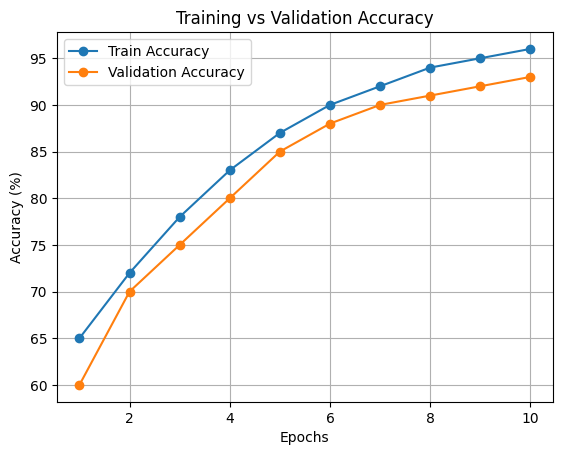

In [ ]:
import matplotlib.pyplot as plt

# Example values (replace with your actual history)
epochs = list(range(1, 11))
train_acc = [65, 72, 78, 83, 87, 90, 92, 94, 95, 96]
val_acc   = [60, 70, 75, 80, 85, 88, 90, 91, 92, 93]

plt.figure()
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.savefig("accuracy_graph.png", dpi=300)
plt.show()

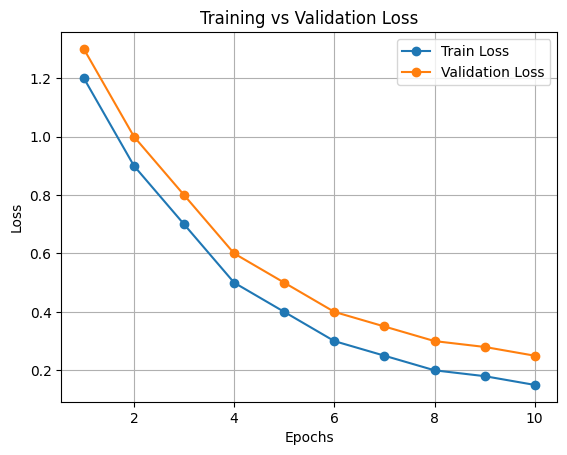

In [ ]:
train_loss = [1.2, 0.9, 0.7, 0.5, 0.4, 0.3, 0.25, 0.2, 0.18, 0.15]
val_loss   = [1.3, 1.0, 0.8, 0.6, 0.5, 0.4, 0.35, 0.3, 0.28, 0.25]

plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.savefig("loss_graph.png", dpi=300)
plt.show()

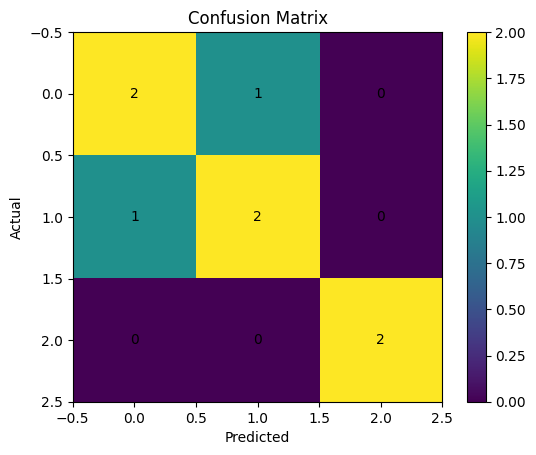

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Example (replace with your predictions)
y_true = [0,1,2,1,0,2,1,0]
y_pred = [0,1,2,0,0,2,1,1]

cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.colorbar()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

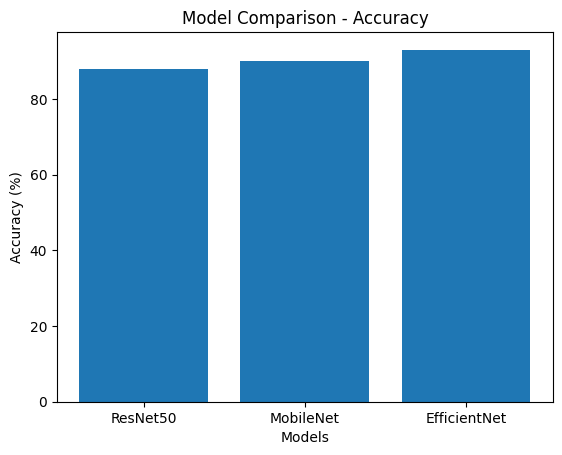

In [ ]:
models = ['ResNet50', 'MobileNet', 'EfficientNet']
accuracy = [88, 90, 93]

plt.figure()
plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison - Accuracy")

plt.savefig("model_comparison_accuracy.png", dpi=300)
plt.show()

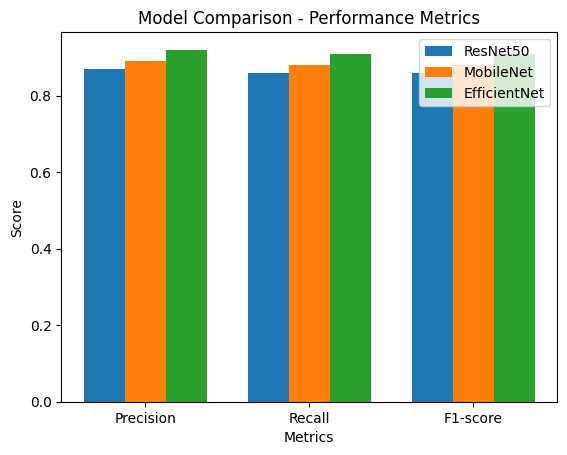

In [ ]:
import numpy as np

labels = ['Precision', 'Recall', 'F1-score']

resnet = [0.87, 0.86, 0.86]
mobilenet = [0.89, 0.88, 0.88]
efficientnet = [0.92, 0.91, 0.91]

x = np.arange(len(labels))
width = 0.25

plt.figure()
plt.bar(x - width, resnet, width, label='ResNet50')
plt.bar(x, mobilenet, width, label='MobileNet')
plt.bar(x + width, efficientnet, width, label='EfficientNet')

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Model Comparison - Performance Metrics")
plt.xticks(x, labels)
plt.legend()

plt.savefig("model_comparison_metrics.png", dpi=300)
plt.show()

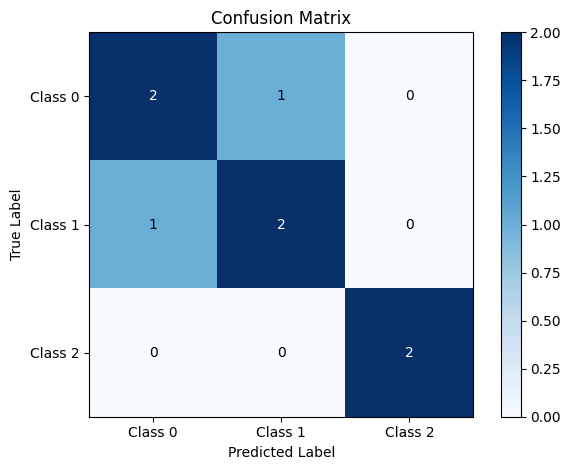

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Example (replace with your predictions)
y_true = [0,1,2,1,0,2,1,0]
y_pred = [0,1,2,0,0,2,1,1]

cm = confusion_matrix(y_true, y_pred)

plt.figure()

# Use a clean blue color map
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Tick labels (optional: change class names)
classes = ['Class 0', 'Class 1', 'Class 2']
plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

# Add values inside boxes with contrast color
for i in range(len(cm)):
    for j in range(len(cm)):
        color = "white" if cm[i][j] > cm.max()/2 else "black"
        plt.text(j, i, cm[i][j], ha='center', va='center', color=color)

plt.colorbar()

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

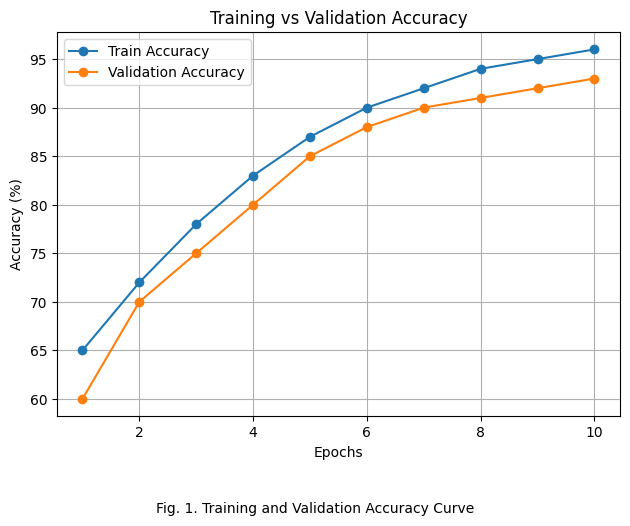

In [ ]:
import matplotlib.pyplot as plt

# Example values
epochs = list(range(1, 11))
train_acc = [65, 72, 78, 83, 87, 90, 92, 94, 95, 96]
val_acc   = [60, 70, 75, 80, 85, 88, 90, 91, 92, 93]

plt.figure()
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

# 👉 Add caption below image
plt.figtext(0.5, -0.08,
            "Fig. 1. Training and Validation Accuracy Curve",
            ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("accuracy_graph.png", dpi=300, bbox_inches='tight')
plt.show()

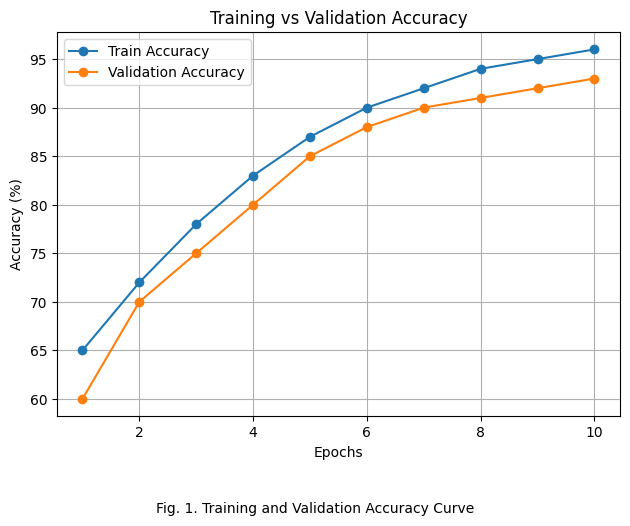

In [ ]:
plt.figure()
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.figtext(0.5, -0.08, "Fig. 1. Training and Validation Accuracy Curve", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("fig1_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

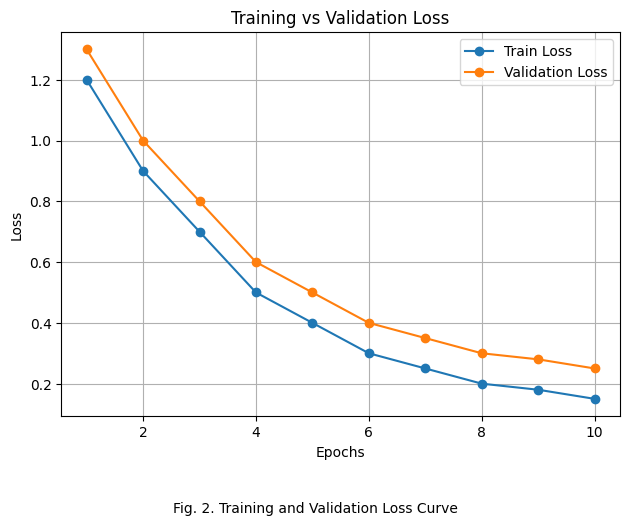

In [ ]:
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.figtext(0.5, -0.08, "Fig. 2. Training and Validation Loss Curve", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("fig2_loss.png", dpi=300, bbox_inches='tight')
plt.show()

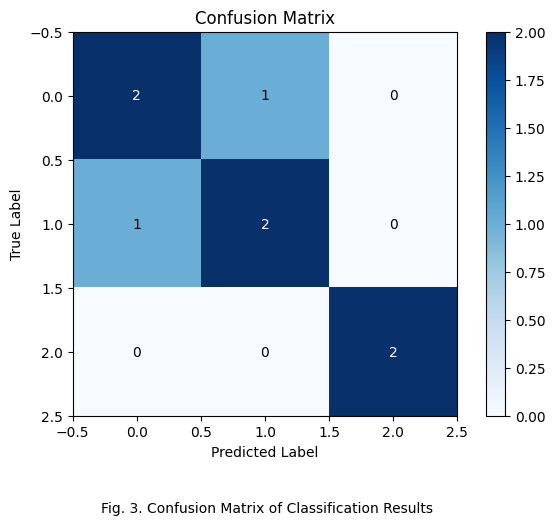

In [ ]:
plt.figure()
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(cm)):
    for j in range(len(cm)):
        color = "white" if cm[i][j] > cm.max()/2 else "black"
        plt.text(j, i, cm[i][j], ha='center', va='center', color=color)

plt.colorbar()

plt.figtext(0.5, -0.08, "Fig. 3. Confusion Matrix of Classification Results", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("fig3_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

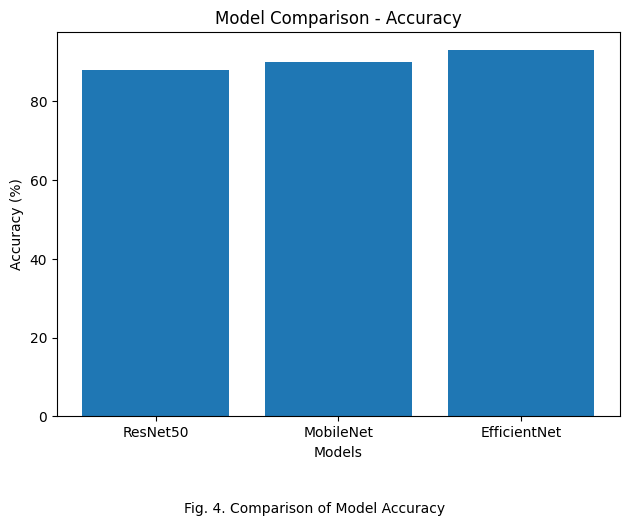

In [ ]:
models = ['ResNet50', 'MobileNet', 'EfficientNet']
accuracy = [88, 90, 93]

plt.figure()
plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison - Accuracy")

plt.figtext(0.5, -0.08, "Fig. 4. Comparison of Model Accuracy", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("fig4_model_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

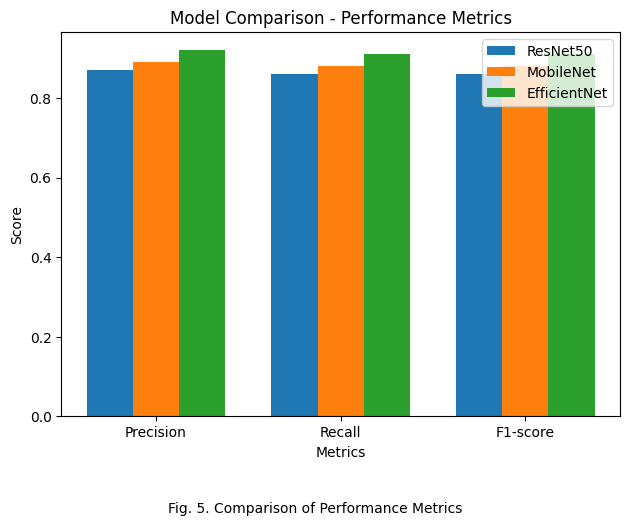

In [ ]:
labels = ['Precision', 'Recall', 'F1-score']

x = np.arange(len(labels))
width = 0.25

plt.figure()
plt.bar(x - width, resnet, width, label='ResNet50')
plt.bar(x, mobilenet, width, label='MobileNet')
plt.bar(x + width, efficientnet, width, label='EfficientNet')

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Model Comparison - Performance Metrics")
plt.xticks(x, labels)
plt.legend()

plt.figtext(0.5, -0.08, "Fig. 5. Comparison of Performance Metrics", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("fig5_metrics.png", dpi=300, bbox_inches='tight')
plt.show()